## The goal is to analyze borrower and loan data to predict the likelihood of loan default, helping financial institutions reduce risk and improve lending strategies.


## Data Analysis & Insights that are expected to be found 

### 1. Loan & Funding Information  
- Distribution of loan amounts requested by borrowers  
- Most common loan terms  
- Average funded vs requested loan amount  
- Difference between funded amount (lenders vs investors)  
- Percentage of loans issued per term  
- Average interest rate by loan grade  
- Average installment amount across loan categories  

### 2. Borrower Characteristics  
- Borrower distribution by credit grade  
- Home ownership vs loan approval / interest rate  
- Income verification vs funding & interest  
- Borrower delinquency distribution  
- Borrowers by employment length  

### 3. Loan Performance & Status  
- Loan status distribution  
- Loan purpose vs repayment outcome  
- Debt-to-Income Ratio (DTI) vs default risk  
- Delinquencies in last 2 years vs repayment  
- Credit inquiries (last 6 months) vs default  
- Open accounts & total accounts vs performance  
- Average repayment by loan grade  
- Bankruptcies vs loan status  

### 4. Engineered Features  
- Principal & interest ratios vs loan status  
- Debt ratio vs repayment behavior  
- Credit history length vs default probability  
- Delinquency flag vs loan performance  
- Grade levels vs delinquency  

### 5. Time-based Analysis  
- Loan issue date vs default trends  
- Loans issued per year  
- Average loan amount over time  
- Loan purpose distribution over time  
- Monthly trend of total funded amount  

### 6. Correlation Analysis  
- Average loan amount by grade & year  
- Loan amount vs funded amount  
- Correlation heatmap with interest rate  
- Loan amount vs installment values  
- Multicollinearity check: `total_rec_prncp`, `principal_paid_ratio`, `loan_amnt`    


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import warnings 
warnings.filterwarnings('ignore')


In [11]:
rawdf = pd.read_csv('Loan_status_2007-2020Q3.gzip')
rawdf.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0,1077501,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,1,1077430,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,2,1077175,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
3,3,1076863,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,4,1075358,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N


In [12]:
rawdf.duplicated().any()

np.False_

In [13]:
rawdf.shape

(2925493, 142)

In [14]:
rawdf.isnull().any().value_counts()

True     140
False      2
Name: count, dtype: int64

In [15]:
rawdf.isnull().all().value_counts()

False    142
Name: count, dtype: int64

In [16]:
mv = ((rawdf.isnull().sum())/len(rawdf))*100
rmv = mv[mv > 30].index
rawdf.drop(rmv, axis=1, inplace=True)

In [17]:
rawdf.shape

(2925493, 105)

In [18]:
rawdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 2925493 entries, 0 to 2925492
Columns: 105 entries, Unnamed: 0 to debt_settlement_flag
dtypes: float64(79), int64(1), object(1), str(24)
memory usage: 2.3+ GB


## Float datatype columns

In [19]:
rawdf_floats = rawdf.select_dtypes(include=['float64'])
rawdf_floats.head()

,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,5000.0,5000.0,4975.0,162.87,24000.0,27.65,0.0,735.0,739.0,1.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,2500.0,2500.0,2500.0,59.83,30000.0,1.00,0.0,740.0,744.0,5.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,2400.0,2400.0,2400.0,84.33,12252.0,8.72,0.0,735.0,739.0,2.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,10000.0,10000.0,10000.0,339.31,49200.0,20.00,0.0,690.0,694.0,1.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,3000.0,3000.0,3000.0,67.79,80000.0,17.94,0.0,695.0,699.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [20]:
rawdf_floats.shape

(2925493, 79)

### Filtering the Float datatype columns

In [21]:
convertible_cols = [
    col for col in rawdf_floats.columns
    if (rawdf_floats[col].dropna() % 1 == 0).all()
]

rawdf[convertible_cols] = rawdf[convertible_cols].astype('Int64')

In [22]:
rawdf_floats.drop(columns=convertible_cols, inplace=True)

In [23]:
rawdf_floats.shape

(2925493, 17)

### Building a pipeline that automatically selects the imputing method based on the properties of each column

In [24]:
for i in rawdf_floats.columns:
    if rawdf_floats[i].nunique() < 10:
        rawdf_floats[i] = rawdf_floats[i].fillna(rawdf_floats[i].mode()[0])
    else:
        f_skew = rawdf_floats[i].skew()
        if -0.5 < f_skew < 0.5:
            rawdf_floats[i] = rawdf_floats[i].fillna(rawdf_floats[i].mean())
        else:
            rawdf_floats[i] = rawdf_floats[i].fillna(rawdf_floats[i].median())

Feature Reduction

In [25]:
rawdf[rawdf_floats.columns] = rawdf_floats

In [26]:
rawdf_floats.drop(['bc_util', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 
            'total_rec_late_fee', 'recoveries'], axis = 1, inplace =True)
rawdf.drop(['bc_util', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 
            'total_rec_late_fee', 'recoveries'], axis = 1, inplace =True)

In [27]:
rawdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 2925493 entries, 0 to 2925492
Data columns (total 100 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Unnamed: 0                  int64  
 1   id                          object 
 2   loan_amnt                   Int64  
 3   funded_amnt                 Int64  
 4   funded_amnt_inv             float64
 5   term                        str    
 6   int_rate                    str    
 7   installment                 float64
 8   grade                       str    
 9   sub_grade                   str    
 10  emp_title                   str    
 11  emp_length                  str    
 12  home_ownership              str    
 13  annual_inc                  float64
 14  verification_status         str    
 15  issue_d                     str    
 16  loan_status                 str    
 17  pymnt_plan                  str    
 18  url                         str    
 19  purpose                     str

## Integer datatype columns

In [28]:
rawdf_int = rawdf.select_dtypes(include = 'int64')
rawdf_int.head()

,Unnamed: 0,loan_amnt,funded_amnt,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,...,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,0,5000,5000,0,735,739,1,3,0,13648,...,<NA>,<NA>,<NA>,<NA>,0,0,<NA>,<NA>,<NA>,<NA>
1,1,2500,2500,0,740,744,5,3,0,1687,...,<NA>,<NA>,<NA>,<NA>,0,0,<NA>,<NA>,<NA>,<NA>
2,2,2400,2400,0,735,739,2,2,0,2956,...,<NA>,<NA>,<NA>,<NA>,0,0,<NA>,<NA>,<NA>,<NA>
3,3,10000,10000,0,690,694,1,10,0,5598,...,<NA>,<NA>,<NA>,<NA>,0,0,<NA>,<NA>,<NA>,<NA>
4,4,3000,3000,0,695,699,0,15,0,27783,...,<NA>,<NA>,<NA>,<NA>,0,0,<NA>,<NA>,<NA>,<NA>


In [29]:
rawdf_int.shape

(2925493, 63)

Dropping unwanted feature which are irrelevant to our analysis

In [30]:
rawdf.drop(['open_il_12m', 'open_il_24m', 'open_rv_24m', 'acc_open_past_24mths', 'num_actv_rev_tl', 
            'num_accts_ever_120_pd', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 
            'total_bc_limit', 'num_rev_tl_bal_gt_0', 'num_actv_bc_tl', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_old_il_acct', 
            'mo_sin_old_rev_tl_op', 'bc_open_to_buy','collections_12_mths_ex_med','tot_coll_amt','all_util','num_bc_sats',
            'tot_hi_cred_lim','total_il_high_credit_limit','total_bal_ex_mort'], axis=1, inplace=True)

In [31]:
rawdf_int.drop(['open_il_12m', 'open_il_24m', 'open_rv_24m', 'acc_open_past_24mths', 'num_actv_rev_tl', 
            'num_accts_ever_120_pd', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 
            'total_bc_limit', 'num_rev_tl_bal_gt_0', 'num_actv_bc_tl', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_old_il_acct', 
            'mo_sin_old_rev_tl_op', 'bc_open_to_buy','collections_12_mths_ex_med','tot_coll_amt','all_util','num_bc_sats',
            'tot_hi_cred_lim','total_il_high_credit_limit','total_bal_ex_mort'], axis=1, inplace=True)

In [32]:
rawdf_int.shape

(2925493, 39)

Similar pipeline to impute Integer as well but this time rounding off mean() to ensure integer datatype

In [33]:
for i in rawdf_int.columns:
    if rawdf_int[i].unique().shape[0] < 10:
        rawdf_int[i] = rawdf_int[i].fillna(rawdf_int[i].mode()[0])
    else:
        col_skew = rawdf_int[i].skew()
        if -0.5 < col_skew < 0.5:
            rawdf_int[i] = rawdf_int[i].fillna(round(rawdf_int[i].mean()))
        else:
            rawdf_int[i] = rawdf_int[i].fillna(rawdf_int[i].median())

In [34]:
rawdf[rawdf_int.columns] = rawdf_int

In [35]:
rawdf.isnull().any().value_counts()

False    52
True     24
Name: count, dtype: int64

## String datatype

In [36]:
rawdf_str = rawdf.select_dtypes(include = 'str')

In [37]:
rawdf_str.head()

,term,int_rate,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,...,zip_code,addr_state,earliest_cr_line,revol_util,initial_list_status,last_pymnt_d,last_credit_pull_d,application_type,hardship_flag,debt_settlement_flag
0,36 months,10.65%,B,B2,NaN,10+ years,RENT,Verified,Dec-2011,Fully Paid,...,860xx,AZ,Jan-1985,83.7%,f,Jan-2015,May-2020,Individual,N,N
1,60 months,15.27%,C,C4,Ryder,< 1 year,RENT,Source Verified,Dec-2011,Charged Off,...,309xx,GA,Apr-1999,9.4%,f,Apr-2013,Oct-2016,Individual,N,N
2,36 months,15.96%,C,C5,NaN,10+ years,RENT,Not Verified,Dec-2011,Fully Paid,...,606xx,IL,Nov-2001,98.5%,f,Jun-2014,Jun-2017,Individual,N,N
3,36 months,13.49%,C,C1,AIR RESOURCES BOARD,10+ years,RENT,Source Verified,Dec-2011,Fully Paid,...,917xx,CA,Feb-1996,21%,f,Jan-2015,Apr-2016,Individual,N,N
4,60 months,12.69%,B,B5,University Medical Group,1 year,RENT,Source Verified,Dec-2011,Fully Paid,...,972xx,OR,Jan-1996,53.9%,f,Jan-2017,Apr-2018,Individual,N,N


Reducing irrelevant string type data

In [38]:
rawdf.drop(['id', 'Unnamed: 0', 'url', 'zip_code', 'addr_state', ], axis=1, inplace=True)

In [39]:
rawdf_str.drop(['url', 'zip_code', 'addr_state'], axis=1, inplace=True)

Imputing Missing Values with Mode( )

In [40]:
rawdf_str.fillna(rawdf[rawdf_str.columns].mode().iloc[0], inplace=True)
rawdf[rawdf_str.columns] = rawdf_str


Typecating data to the appropriate type

In [41]:
rawdf_str['int_rate'] = rawdf_str['int_rate'].str.replace('%', '', regex=True).astype(float)
rawdf_str['revol_util'] = rawdf_str['revol_util'].str.replace('%', '', regex=True).astype(float)

In [42]:
rawdf['int_rate'] = rawdf['int_rate'].str.replace('%', '', regex=True).astype(float)
rawdf['revol_util'] = rawdf['revol_util'].str.replace('%', '', regex=True).astype(float)

In [43]:
rawdf.isnull().any().value_counts()

False    71
Name: count, dtype: int64

In [44]:
processed_df = rawdf.copy()

# **Analysis**

## 1. Loan and Funding Information

### 1.1 Distribution of loan amounts requested by borrowers

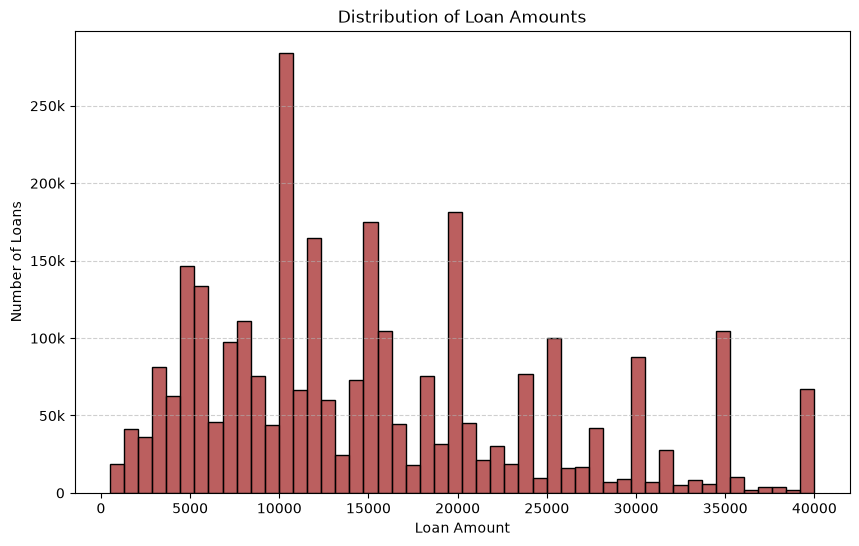

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(data=processed_df,x='loan_amnt',color='brown',bins=50)
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Loans')
formatter = ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}k' if x > 0 else '0')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

- Most of the people seems to be borrowing around 10,000$
- Which is folllowed by 20k, 15k, 13k and so on...

### 1.2 Most Common Loan terms

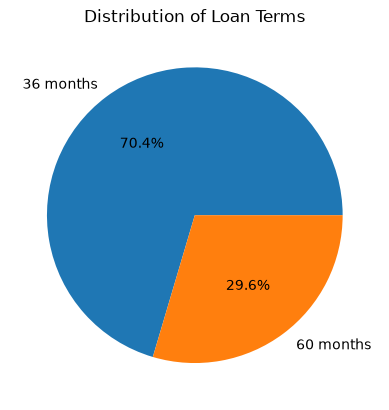

In [46]:
plt.pie(processed_df['term'].value_counts(), labels = processed_df['term'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribution of Loan Terms')
plt.show()

- 70% of people out of 2925493 are opting for the longer 36 months term

### 1.3 Average funded vs requested loan amount

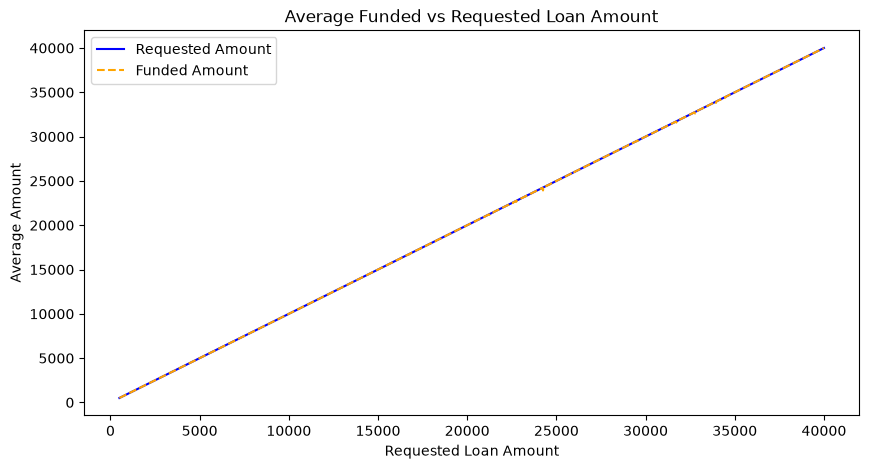

In [47]:
grouped_data = (processed_df.groupby("loan_amnt")[["loan_amnt", "funded_amnt"]].mean())

plt.figure(figsize=(10, 5))
sns.lineplot(x=grouped_data["loan_amnt"],y=grouped_data["loan_amnt"],label="Requested Amount",color="blue")
sns.lineplot(x=grouped_data["loan_amnt"],y=grouped_data["funded_amnt"],label="Funded Amount",color="orange",
             linestyle="--")

plt.title("Average Funded vs Requested Loan Amount")
plt.xlabel("Requested Loan Amount")
plt.ylabel("Average Amount")
plt.legend()
plt.show()

In [48]:
(processed_df['loan_amnt']==processed_df['funded_amnt']).value_counts()

True     2923428
False       2065
Name: count, dtype: Int64

In [49]:
((processed_df['loan_amnt']==processed_df['funded_amnt']).value_counts(normalize = True))*100

True     99.929414
False     0.070586
Name: proportion, dtype: Float64

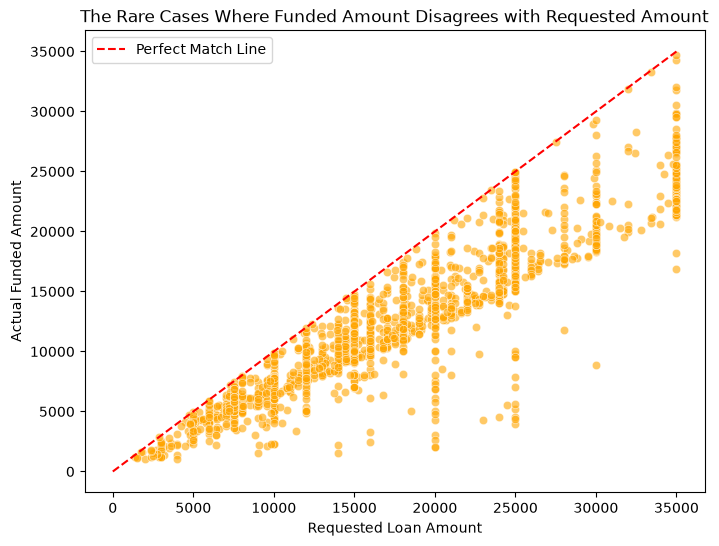

In [50]:
anomalies = processed_df[rawdf["loan_amnt"] != processed_df["funded_amnt"]]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=anomalies, x="loan_amnt", y="funded_amnt", alpha=0.6, color="orange")

max_val = max(anomalies["loan_amnt"].max(), anomalies["funded_amnt"].max())

plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Match Line")
plt.title("The Rare Cases Where Funded Amount Disagrees with Requested Amount")
plt.xlabel("Requested Loan Amount")
plt.ylabel("Actual Funded Amount")
plt.legend()
plt.show()

In [51]:
processed_df[(processed_df['loan_amnt'] == 20000) & (processed_df['funded_amnt'] < 5000)][['loan_amnt', 'funded_amnt']]

,loan_amnt,funded_amnt
23363,20000,2050
23404,20000,3050
23483,20000,2650
23528,20000,4300
23623,20000,2025
39662,20000,4800


- Double checking the chart

- From the above graphs we can see that about 99.92% of Loan amounts always get funded and this is not a surprise since platforms like Lending Club are filled with multiple investors moreover the platform itself will also fund these loan.

### 1.4 Difference between funded amounts (Lenders vs Investors)

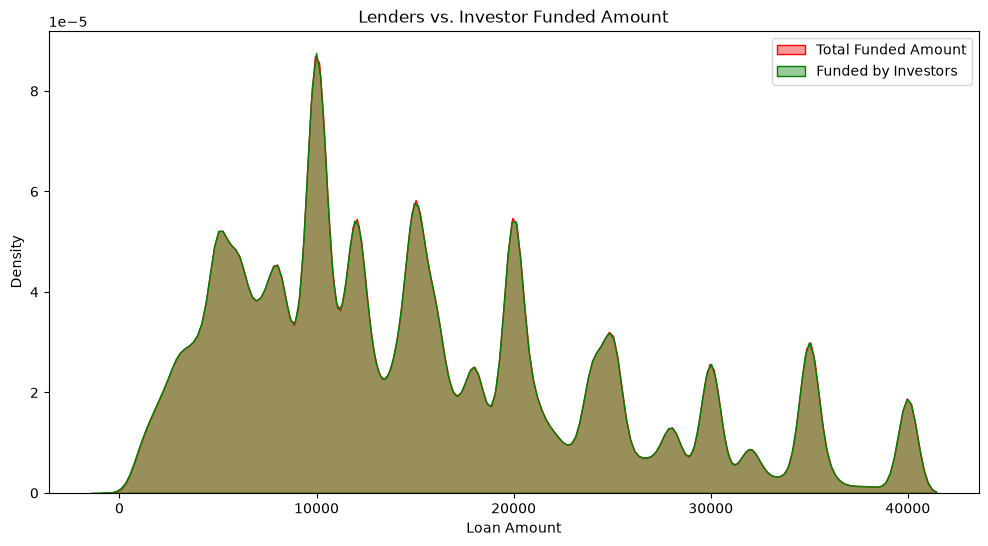

In [52]:
plt.figure(figsize=(12, 6))

sns.kdeplot(data=processed_df, x='funded_amnt', fill=True, color='red', label='Total Funded Amount', alpha=0.4)
sns.kdeplot(data=processed_df, x='funded_amnt_inv', fill=True, color='green', label='Funded by Investors', alpha=0.4)

plt.title('Lenders vs. Investor Funded Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Density')
plt.legend()
plt.show()

- Primary Insight: The distributions for funded_amnt and funded_amnt_inv are nearly identical, telling us that the individual investors successfully fund virtually all capital for the requested loans.

- Minor capital shortfalls (indicated by the red peaks at $10k, $15k, and $20k) occur exclusively at major round-number milestones. This reflects high volume demand at psychological thresholds where the lending club is occasionally required to achieve 100% loan fulfillment.

### 1.5 Percentage of loans issued per term

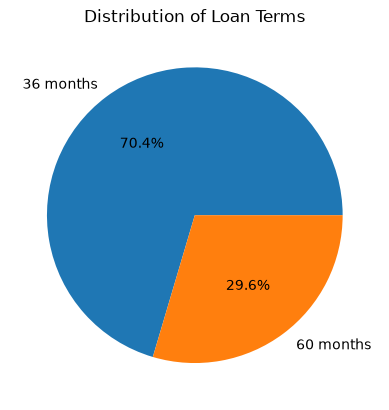

In [53]:
plt.pie(processed_df['term'].value_counts(), labels = processed_df['term'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribution of Loan Terms')
plt.show()

### 1.6 Average interest rate by loan grade

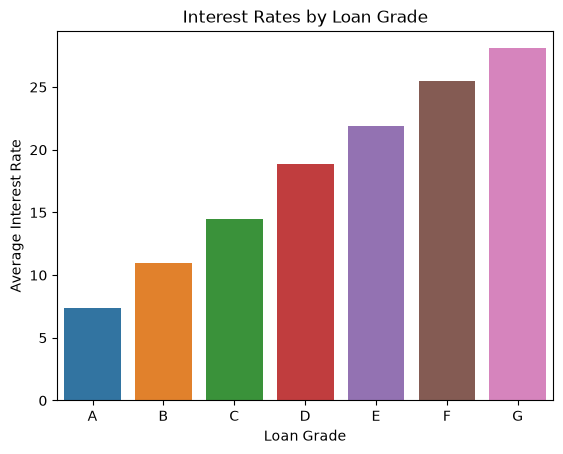

In [54]:
grouped_data = processed_df.groupby('grade')['int_rate'].mean().reset_index(name = 'Average Interest Rate')
sns.barplot(data = grouped_data, x = 'grade', y = 'Average Interest Rate', hue = 'grade')
plt.xlabel('Loan Grade')
plt.title('Interest Rates by Loan Grade')
plt.show()

### 1.7 Average installment amount across loan categories

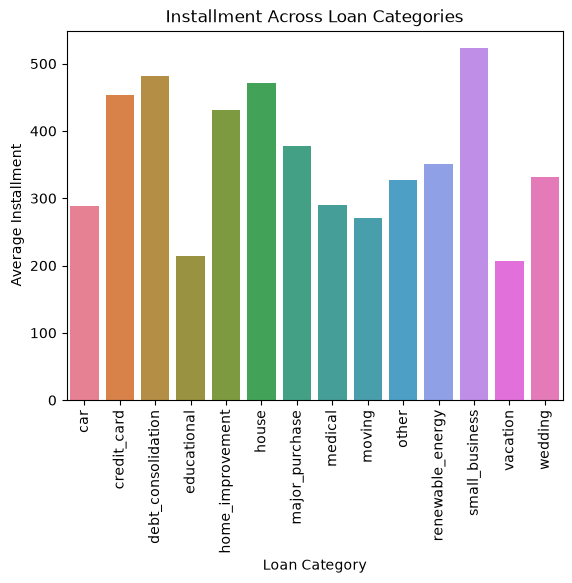

In [55]:
grouped_data = processed_df.groupby('purpose')['installment'].mean().reset_index(name = 'Average Installment')
sns.barplot(data = grouped_data, x = 'purpose', y = 'Average Installment', hue = 'purpose')
plt.title('Installment Across Loan Categories')
plt.xlabel('Loan Category')
plt.xticks(rotation=90)
plt.show()

# 2. Borrower Characteristics

### 2.1 Borrower distribution by credit grade

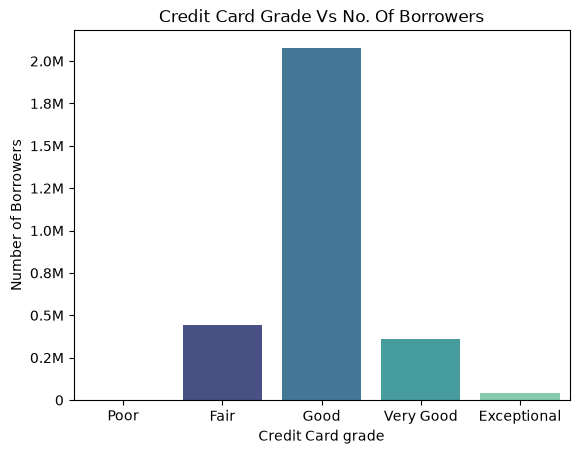

In [56]:

processed_df['fico_score'] = ((processed_df['fico_range_low']) + (processed_df['fico_range_high']))/2
processed_df['cc_grade'] = pd.cut(processed_df['fico_score'], bins=[300, 580, 670, 740, 800, 850], 
                                  labels = ['Poor','Fair','Good','Very Good','Exceptional'])
grouped_data = processed_df.groupby('cc_grade').size().reset_index(name = "Number of Borrowers")
formatter = ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x > 0 else '0')
plt.gca().yaxis.set_major_formatter(formatter)
plot = sns.barplot(data = grouped_data, x = 'cc_grade', y = 'Number of Borrowers',palette = 'mako')
plt.title('Credit Card Grade Vs No. Of Borrowers')
plt.xlabel('Credit Card grade')
plt.show()


### 2.2 Home ownership vs loan approval / interest rate

In [57]:
status_map = {
    'Fully Paid': 'Good Standing',
    'Current': 'Good Standing',
    'Does not meet credit policy. Status:Fully Paid': 'Good Standing',
    'In Grace Period': 'Warning',
    'Late (16-30 days)': 'Warning',
    'Late (31-120 days)': 'Warning',
    'Charged Off': 'Bad Standing',
    'Default': 'Bad Standing',
    'Does not meet credit policy. Status:Charged Off': 'Bad Standing',
    'Issued': 'Good Standing'
}
processed_df['simplified_loan_status'] = processed_df['loan_status'].map(status_map)
home_status = processed_df.groupby(['home_ownership', 'simplified_loan_status']).size().reset_index(name='count')
print(home_status)

   home_ownership simplified_loan_status    count
0             ANY           Bad Standing      240
1             ANY          Good Standing     3201
2             ANY                Warning       78
3        MORTGAGE           Bad Standing   154706
4        MORTGAGE          Good Standing  1268934
5        MORTGAGE                Warning    12964
6            NONE           Bad Standing        7
7            NONE          Good Standing       43
8           OTHER           Bad Standing       27
9           OTHER          Good Standing      117
10            OWN           Bad Standing    41398
11            OWN          Good Standing   286014
12            OWN                Warning     3682
13           RENT           Bad Standing   166603
14           RENT          Good Standing   972553
15           RENT                Warning    12177


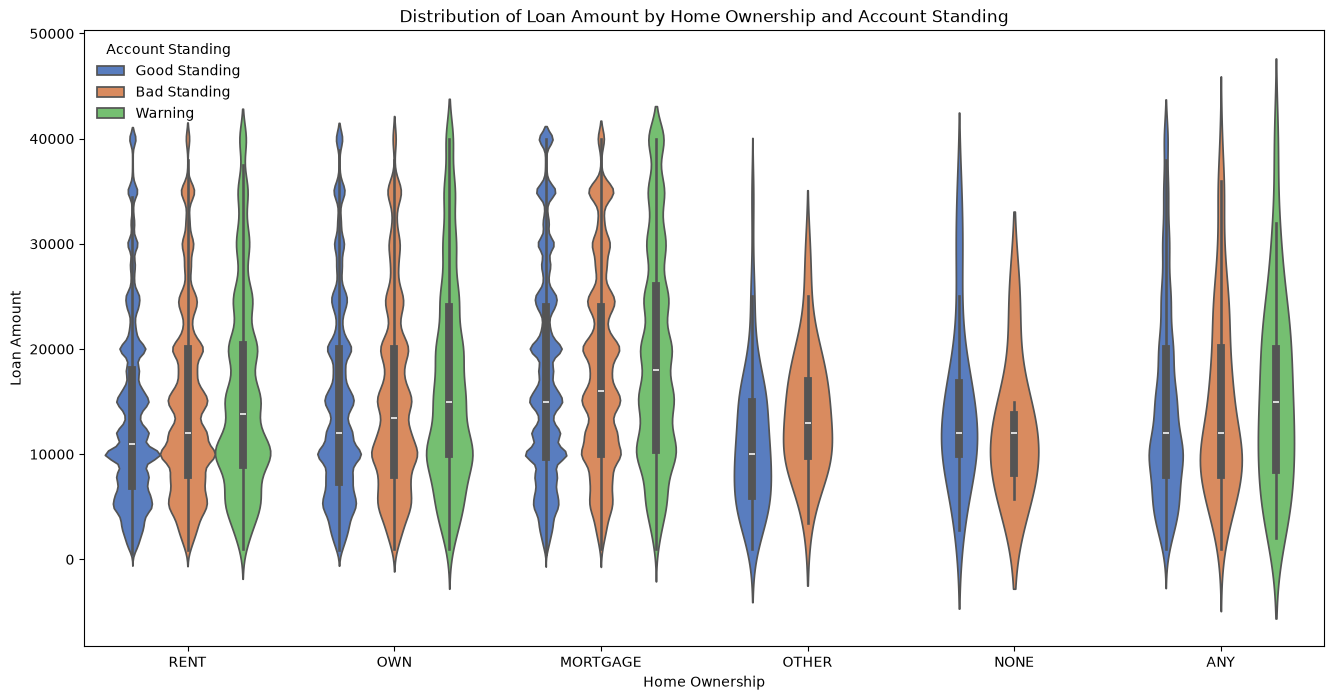

In [58]:
plt.figure(figsize=(16, 8))
sns.violinplot(data=processed_df,x='home_ownership',y='loan_amnt',hue='simplified_loan_status',split=False,
               width=0.8,inner='box',palette="muted")
plt.title("Distribution of Loan Amount by Home Ownership and Account Standing")
plt.xlabel("Home Ownership")
plt.ylabel("Loan Amount")
plt.legend(title="Account Standing", loc='upper left', frameon=False)
plt.show()

- Volume & Underwriting Bias: The vast majority of portfolio volume is concentrated within Renters and Mortgage-holders. Borrowers with Mortgages consistently command higher median loan amounts (~$15k–$18k) compared to Renters (~$10k–$12k).

- Risk Indicator: Across all primary housing types, accounts currently flagged as 'Warning' (delinquent/in grace periods) display higher median loan sizes than those in Good or Bad standing, indicating that larger loan balances correlate with active repayment distress.

- Behavioral Clustering: Distinct horizontal ridges across the primary violins highlight intense clustering at round-number psychological thresholds ($10k, $15k, $20k, $35k).

### 2.3 Income verification vs Funding and Interest

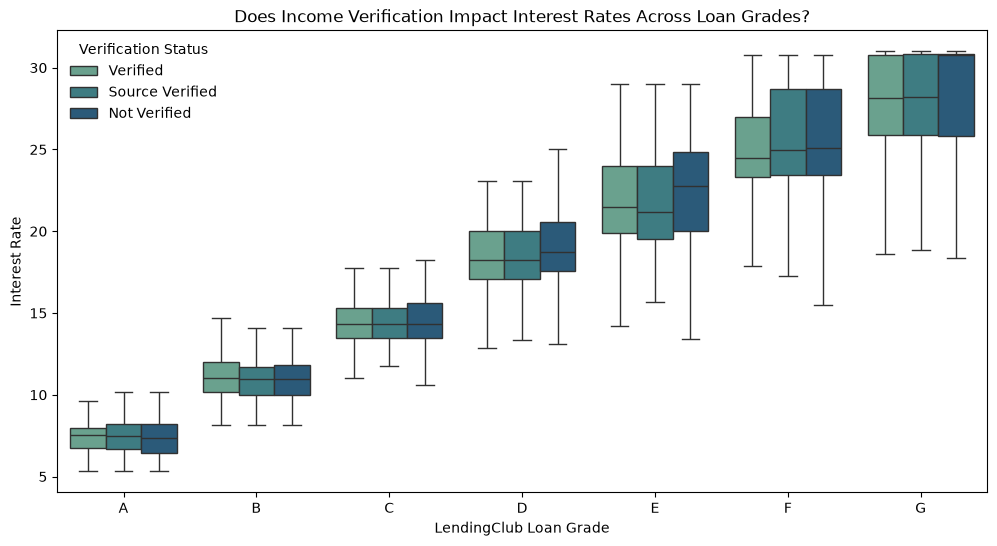

In [59]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=processed_df,x='grade',y='int_rate',hue='verification_status',
            order=sorted(processed_df['grade'].unique()),palette='crest', showfliers = False)
plt.title('Does Income Verification Impact Interest Rates Across Loan Grades?')
plt.xlabel('LendingClub Loan Grade')
plt.ylabel('Interest Rate')
plt.legend(title='Verification Status', loc='upper left', frameon = False)
plt.show()

In [60]:
processed_df['funding_ratio'] = (processed_df['funded_amnt'] / processed_df['loan_amnt']) * 100
funding_stats = processed_df.groupby('verification_status')['funding_ratio'].mean().reset_index()

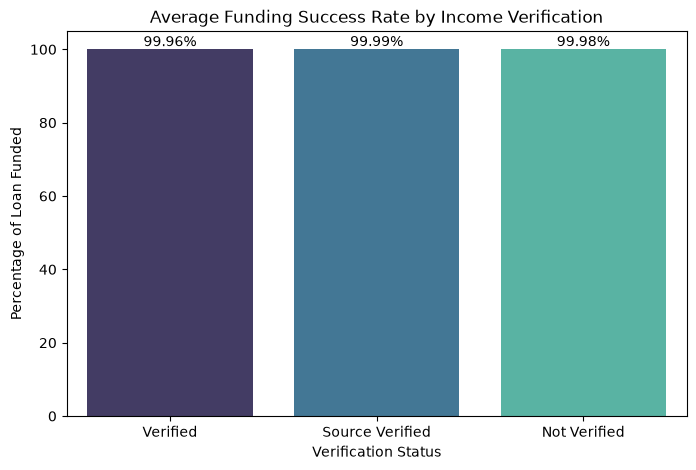

In [61]:
plt.figure(figsize=(8, 5))
plot = sns.barplot(data=processed_df,x='verification_status',y='funding_ratio',palette='mako',errorbar=None)
plt.title('Average Funding Success Rate by Income Verification')
plt.xlabel('Verification Status')
plt.ylabel('Percentage of Loan Funded')
for i in plot.containers:
    plot.bar_label(i, fmt='%.2f%%')
plt.show()

In [62]:
summary_table = processed_df.groupby('verification_status').agg(
    median_interest_rate=('int_rate', 'median'),
    median_loan_size=('loan_amnt', 'median'),
    total_loans=('loan_amnt', 'count')
).reset_index()

print(summary_table)

  verification_status  median_interest_rate  median_loan_size  total_loans
0        Not Verified                 11.05           12000.0      1065687
1     Source Verified                 12.62           14000.0      1143248
2            Verified                 14.07           15950.0       716558


- From this particular analysis we can see that the lending club system giving higher intrest rate to the people who are verified whereas lower interest rate to the people who are not verified.
- Moreover the verified customers are seemed to be having an higher loan size compared to others.
- Combining both the points we can determine that the people who tend to ask **higher loan amount** are asked or pushed to be "verified" and are given a **higher interes**t rate as a defensive mechanism while the "non verified" customers who tend to ask **lower** **loan amounts** are given **lower interest rates**
- So we can see this as "*Funding size Vs Income verification and Interest*" rather than "*Income verification vs funding and Interest"*


### 2.4 Borrower delinquency distribution

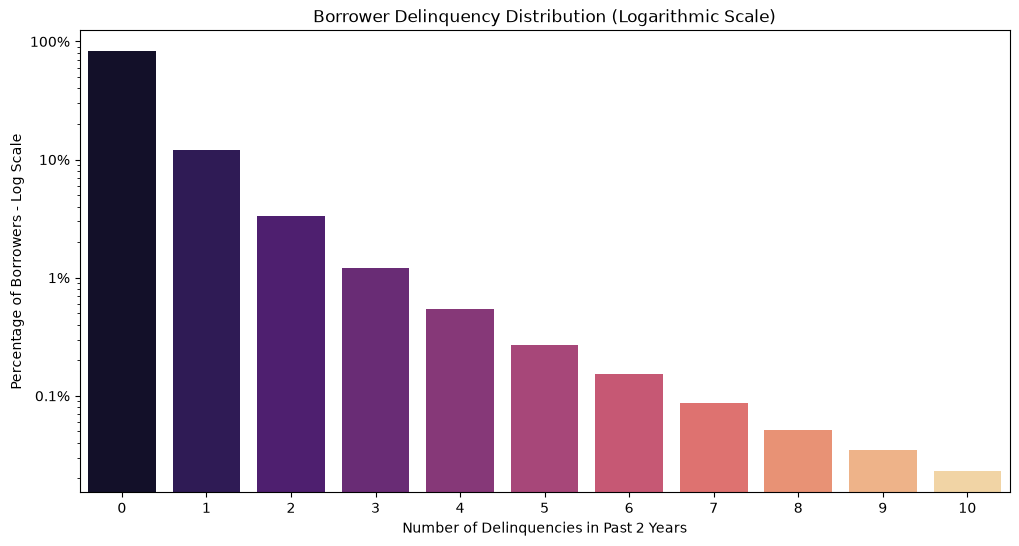

In [63]:
data = rawdf['delinq_2yrs'].value_counts(normalize= True).mul(100).sort_index().reset_index(name='Percentage of Borrowers')
filtered_data = data[data['delinq_2yrs'] <= 10]
plt.figure(figsize=(12,6))
sns.barplot(data=filtered_data, x='delinq_2yrs', y='Percentage of Borrowers', palette='magma')
plt.yscale('log')
plt.title('Borrower Delinquency Distribution (Logarithmic Scale)')
plt.xlabel('Number of Delinquencies in Past 2 Years')
plt.ylabel('Percentage of Borrowers - Log Scale')
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%g%%'))
plt.show()

### 2.5 Borrowers by employment length

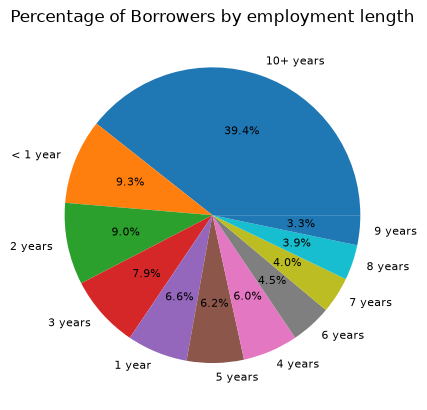

In [64]:
data = processed_df['emp_length'].value_counts(normalize = True).mul(100).sort_values(ascending=False).reset_index()
wedges, texts, autotexts = plt.pie(data=data,x=data.proportion,labels='emp_length', autopct='%1.1f%%',textprops={'fontsize': 8})
plt.title('Percentage of Borrowers by employment length')
plt.show()
plt.show()

## 3. Loan Performance and Status

### 3.1 Loan status distribution

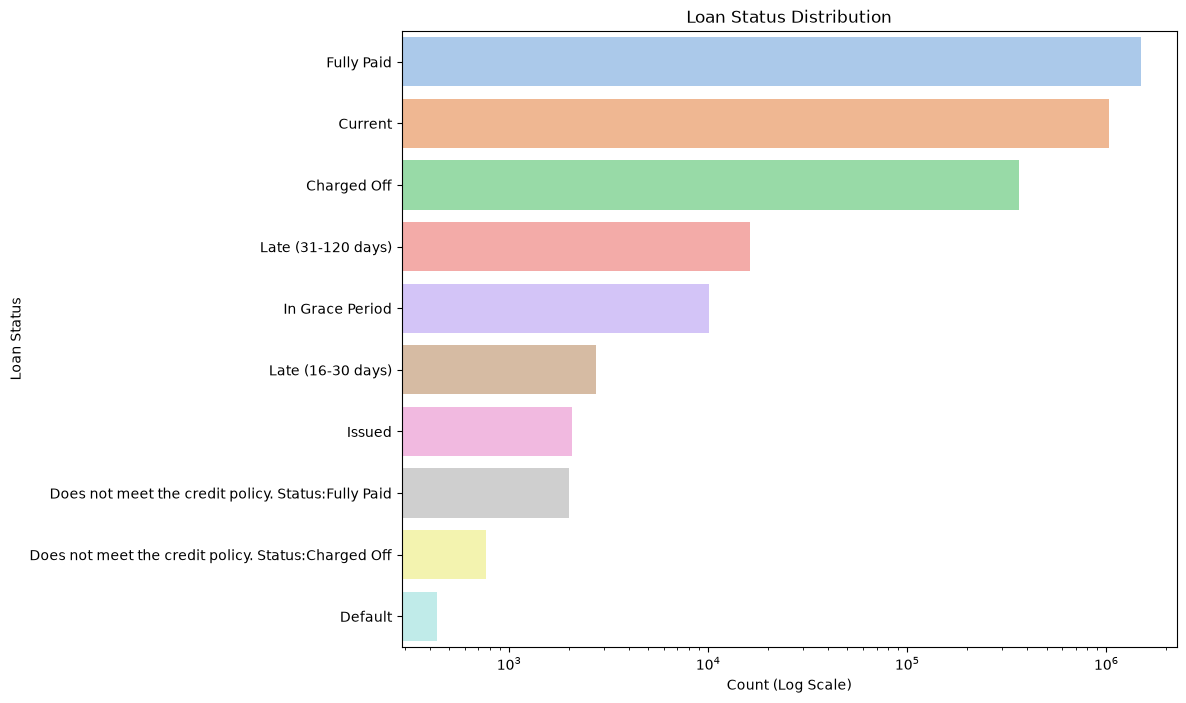

In [65]:
plt.figure(figsize=(10, 8))
sns.countplot(data=rawdf, y='loan_status', palette='pastel',order=rawdf['loan_status'].value_counts().index)
plt.xscale('log')
plt.title('Loan Status Distribution')
plt.xlabel('Count (Log Scale)')
plt.ylabel('Loan Status')
plt.show()

### 3.2 Loan purpose vs repayment outcome 

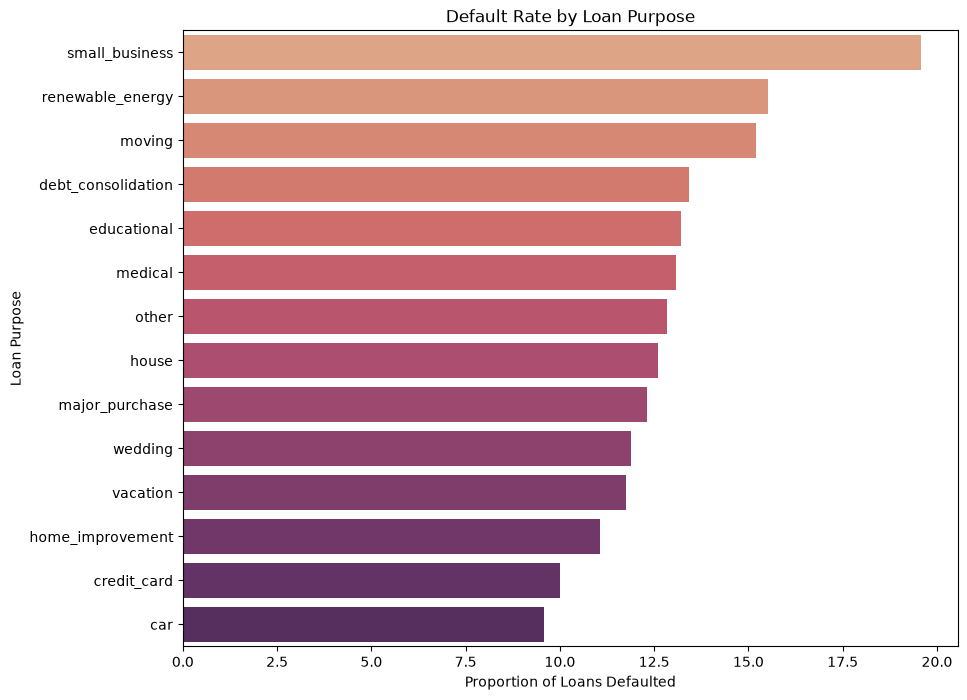

In [66]:
processed_df['is_default'] = processed_df['simplified_loan_status'].apply(lambda x: 1 if x == 'Bad Standing' else 0)
purpose_risk = processed_df.groupby('purpose')['is_default'].mean().mul(100).sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(data=purpose_risk,y='purpose',x='is_default',palette='flare')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Proportion of Loans Defaulted')
plt.ylabel('Loan Purpose')
plt.show()

In [ ]:
purpose_risk_map = {}
for i in purpose_risk.values:
    purpose_risk_map.update({i[0]:i[1]})
purpose_risk_map


{'small_business': 19.575660528422738,
 'renewable_energy': 15.506508205998868,
 'moving': 15.205379482902417,
 'debt_consolidation': 13.415939230516116,
 'educational': 13.20754716981132,
 'medical': 13.069839920668649,
 'other': 12.831853421076357,
 'house': 12.604613186364563,
 'major_purchase': 12.315545983887692,
 'wedding': 11.8895966029724,
 'vacation': 11.76470588235294,
 'home_improvement': 11.065803108808291,
 'credit_card': 10.012865387794413,
 'car': 9.589638626983861}

In [68]:
processed_df['purpose_risk'] = processed_df['purpose'].map(purpose_risk_map)
processed_df['purpose_risk'].head()

0    10.012865
1     9.589639
2    19.575661
3    12.831853
4    12.831853
Name: purpose_risk, dtype: float64

### 3.3 Debt-to-Income Ratio (DTI) vs default risk

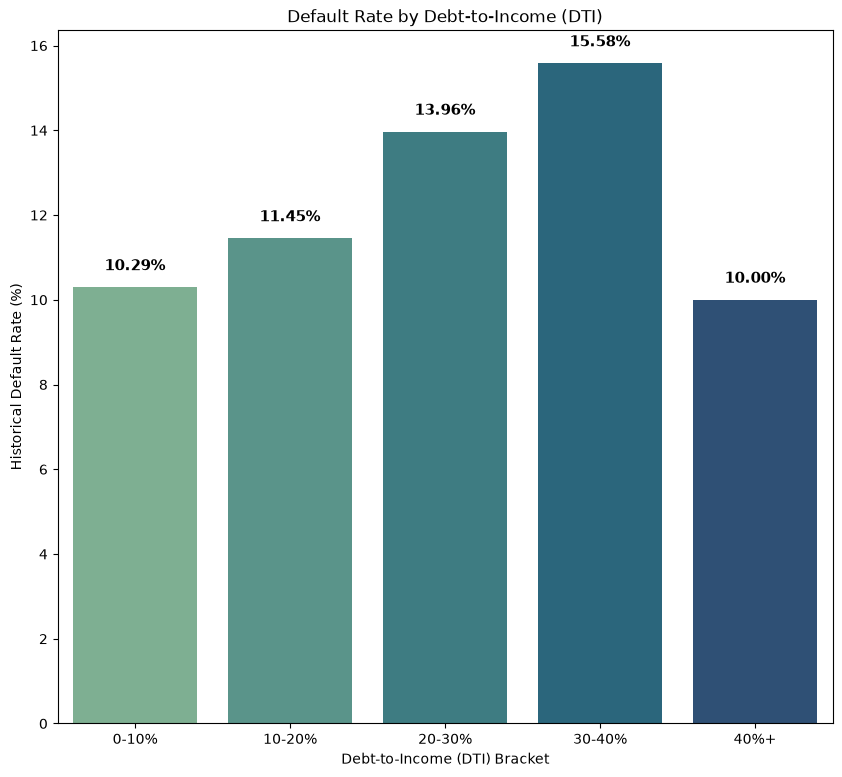

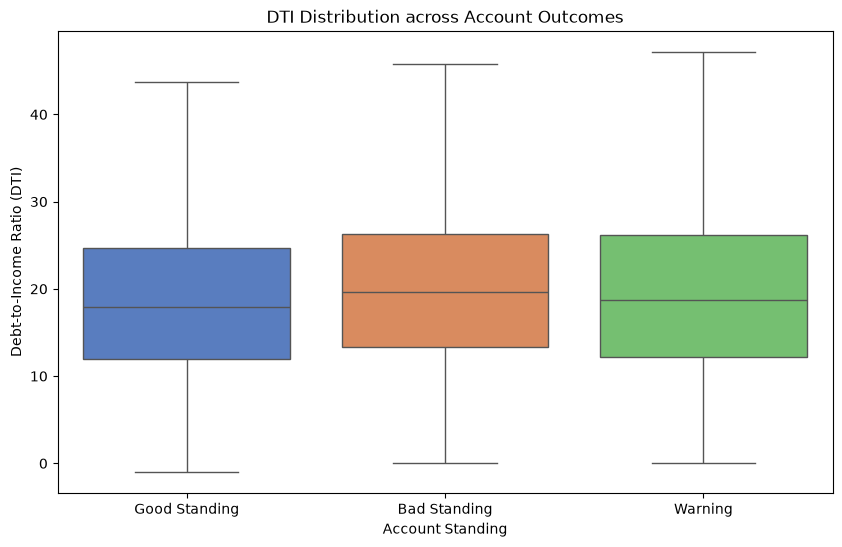

In [69]:
processed_df['dti_bins'] = pd.cut(processed_df['dti'],bins=[-np.inf, 10, 20, 30, 40, np.inf],
                                  labels=['0-10%', '10-20%', '20-30%', '30-40%', '40%+'], include_lowest=True)

dti_risk = processed_df.groupby('dti_bins')['is_default'].mean().mul(100).reset_index()
plt.figure(figsize=(10, 9))
ax = sns.barplot(data=dti_risk, x='dti_bins', y='is_default', palette='crest')
plt.title('Default Rate by Debt-to-Income (DTI)')
plt.xlabel('Debt-to-Income (DTI) Bracket')
plt.ylabel('Historical Default Rate (%)')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.5), 
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=processed_df,x='simplified_loan_status',y='dti',palette='muted',showfliers=False)
plt.title('DTI Distribution across Account Outcomes')
plt.xlabel('Account Standing')
plt.ylabel('Debt-to-Income Ratio (DTI)')
plt.show()


### 3.4 Delinquencies in last 2 years vs repayment

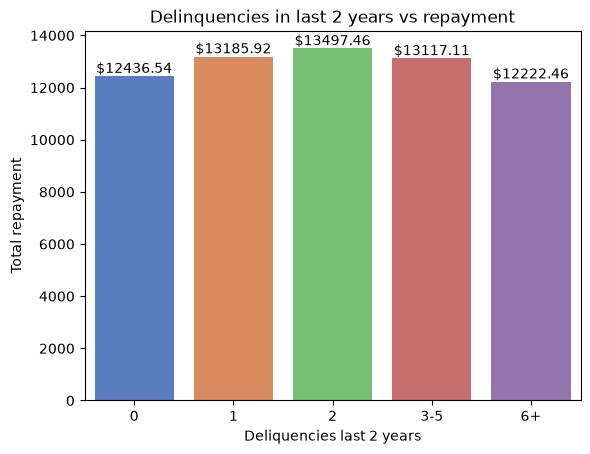

In [70]:
processed_df['delinq_2yrs_bins'] = pd.cut(processed_df['delinq_2yrs'],bins=[-1, 0, 1, 2, 5, processed_df['delinq_2yrs'].max()], 
                                          labels=['0', '1', '2', '3-5', '6+'])
plot = sns.barplot(data=processed_df,x='delinq_2yrs_bins',y='total_pymnt', palette='muted',errorbar=None)
plt.title('Delinquencies in last 2 years vs repayment')
plt.xlabel('Deliquencies last 2 years')
plt.ylabel('Total repayment')
for i in plot.containers:
    plot.bar_label(i, fmt='$%.2f')
plt.show()

### 3.5 Credit inquiries (last 6 months) vs default

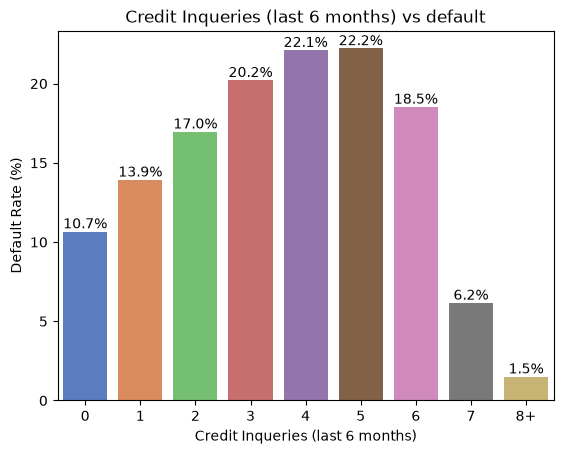

In [71]:
processed_df['inq_bins'] = pd.cut(processed_df['inq_last_6mths'], bins=[-1,0,1,2,3,4,5,6,7,processed_df['inq_last_6mths'].max()], 
                  labels=['0','1','2','3','4','5','6','7','8+'])
inq_risk = processed_df.groupby('inq_bins')['is_default'].mean().mul(100).sort_values(ascending=False).reset_index()
plot = sns.barplot(data=inq_risk,x='inq_bins',y='is_default',palette='muted',errorbar=None)
plt.title('Credit Inqueries (last 6 months) vs default')
plt.xlabel('Credit Inqueries (last 6 months)')
plt.ylabel('Default Rate (%)')

for i in plot.containers:
    plot.bar_label(i, fmt='%.1f%%')
plt.show()

### 3.6 Open accounts and total accounts vs performance

In [72]:
np.linspace(0,27,10).astype('int')

array([ 0,  3,  6,  9, 12, 15, 18, 21, 24, 27])

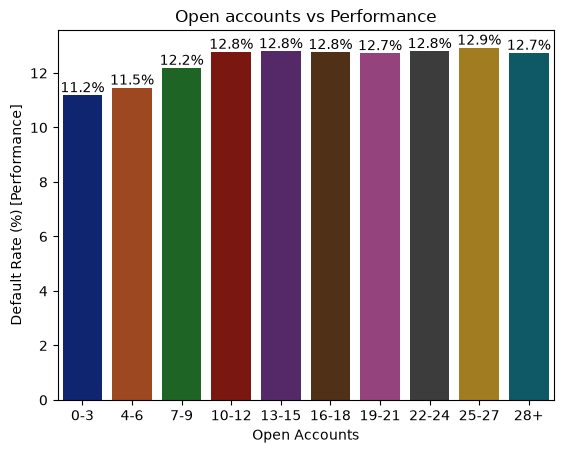

In [73]:
processed_df['open_acc_bin'] = pd.cut(processed_df['open_acc'], bins=[ 0, 3, 6, 9, 12, 15, 18, 21, 24, 27,processed_df['open_acc'].max()], 
                                      labels=[ '0-3','4-6','7-9','10-12','13-15','16-18','19-21','22-24','25-27','28+'], include_lowest=True)
open_acc_prfm = processed_df.groupby('open_acc_bin', observed=False)['is_default'].mean().mul(100).reset_index()
plot = sns.barplot(data=open_acc_prfm,x='open_acc_bin',y='is_default',palette='dark',errorbar=None)
plt.title('Open accounts vs Performance')
plt.xlabel('Open Accounts')
plt.ylabel('Default Rate (%) [Performance]')

for i in plot.containers:
    plot.bar_label(i, fmt='%.1f%%')
plt.show()


In [74]:
np.linspace(0,50,10).astype('int')

array([ 0,  5, 11, 16, 22, 27, 33, 38, 44, 50])

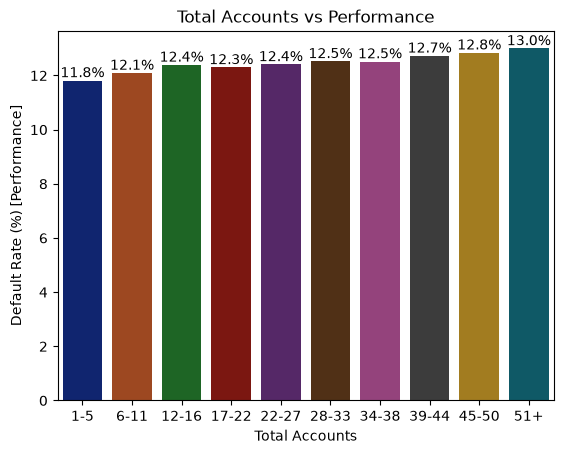

In [75]:
processed_df['total_acc_bin'] = pd.cut(processed_df['total_acc'], bins=[ 0,  5, 11, 16, 22, 27, 33, 38, 44, 50,processed_df['total_acc'].max()], 
                                      labels=[ '1-5','6-11','12-16','17-22','22-27','28-33','34-38','39-44','45-50','51+'])
total_acc_prfm = processed_df.groupby('total_acc_bin', observed=False)['is_default'].mean().mul(100).reset_index()
plot = sns.barplot(data=total_acc_prfm,x='total_acc_bin',y='is_default',palette='dark',errorbar=None)
plt.title('Total Accounts vs Performance')
plt.xlabel('Total Accounts')
plt.ylabel('Default Rate (%) [Performance]')

for i in plot.containers:
    plot.bar_label(i, fmt='%.1f%%')
plt.show()

### 3.7 Average repayment by loan grade

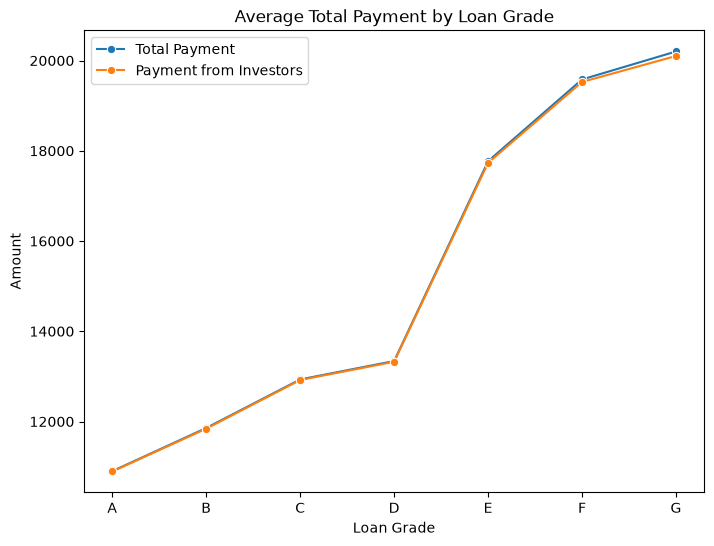

In [76]:
avg_payment = processed_df.groupby('grade')[['total_pymnt', 'total_pymnt_inv']].mean().reset_index()

plt.figure(figsize=(8,6))
sns.lineplot(x='grade', y='total_pymnt', data=avg_payment, marker='o', label='Total Payment')
sns.lineplot(x='grade', y='total_pymnt_inv', data=avg_payment, marker='o', label='Payment from Investors')
plt.title('Average Total Payment by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Amount')
plt.legend()
plt.show()

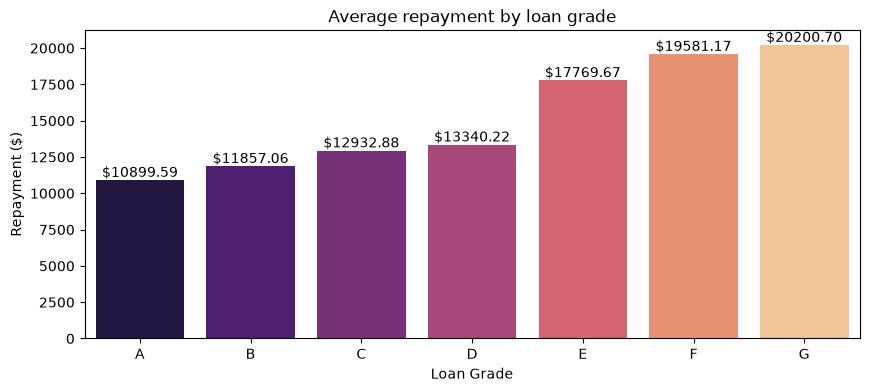

In [77]:
plt.figure(figsize=(10,4))
grouped_data = processed_df.groupby('grade')['total_pymnt'].mean().reset_index()
plot = sns.barplot(data=grouped_data,x='grade',y='total_pymnt',palette='magma')
plt.title('Average repayment by loan grade')
plt.xlabel('Loan Grade')
plt.ylabel('Repayment ($)')
for i in plot.containers:
    plot.bar_label(i, fmt = '$%.2f')
plt.show()

### 3.8 Bankruptcies vs loan status

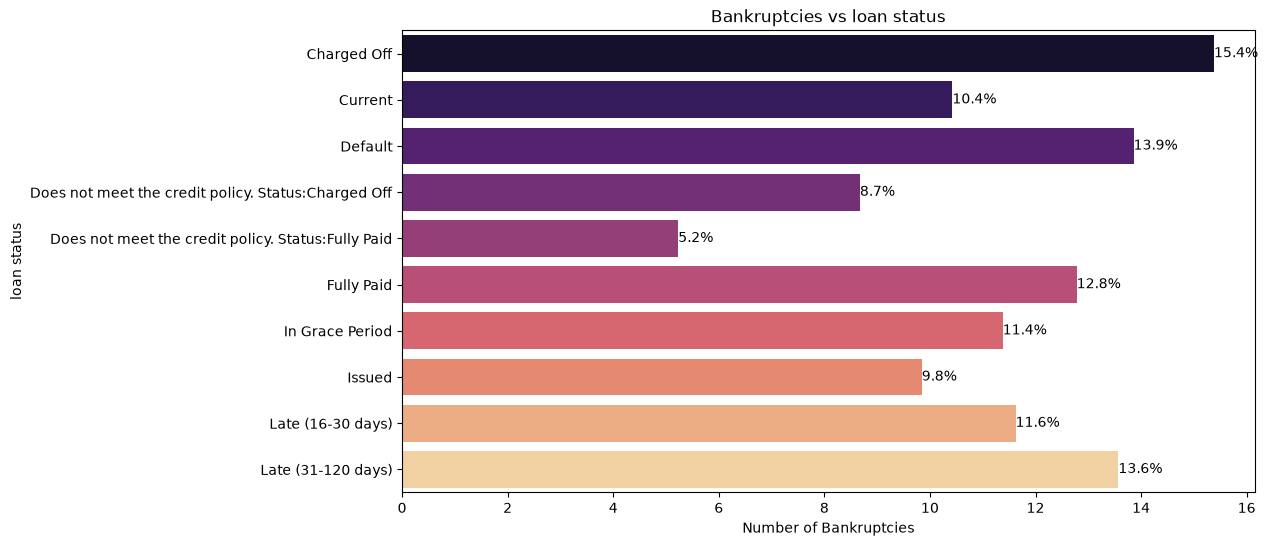

In [78]:
grouped_data = processed_df.groupby('loan_status')['pub_rec_bankruptcies'].mean().mul(100).reset_index()
plt.figure(figsize=(11,6))
plot = sns.barplot(data=grouped_data,x='pub_rec_bankruptcies',y='loan_status',palette='magma')
plt.title('Bankruptcies vs loan status')
plt.xlabel('Number of Bankruptcies')
plt.ylabel('loan status')
for i in plot.containers:
    plot.bar_label(i, fmt='%.1f%%')
plt.show()

## 4. Engineered Features

### 4.1 Principal and interest ratios vs loan status

In [79]:
processed_df['int_ratio'] = (processed_df['total_rec_int']/processed_df['total_pymnt']).round(2)
processed_df['int_ratio'].head()

0    0.15
1    0.43
2    0.20
3    0.18
4    0.26
Name: int_ratio, dtype: float64

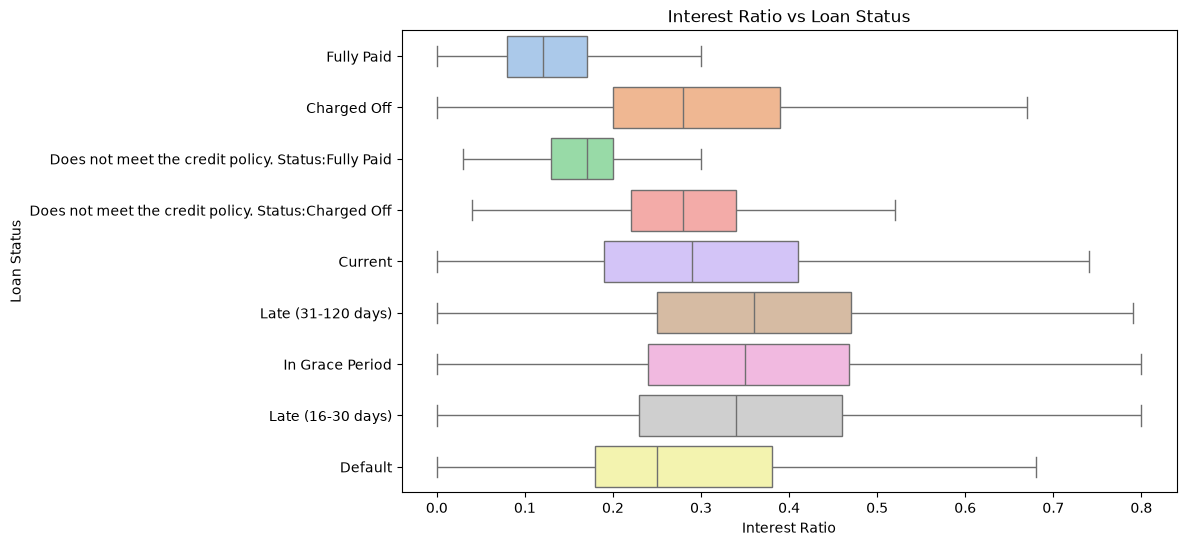

In [80]:
plt.figure(figsize=(10,6))
plot = sns.boxplot(data = processed_df[processed_df['loan_status'] != 'Issued'],
                   x='int_ratio',y='loan_status',palette='pastel',showfliers=False)
plt.title('Interest Ratio vs Loan Status')
plt.xlabel('Interest Ratio')
plt.ylabel('Loan Status')
plt.show()

In [81]:
processed_df.groupby('loan_status')['int_ratio'].agg(Median='median',Mean='mean',Q1=lambda x: x.quantile(0.25),
                                                     Q3=lambda x: x.quantile(0.75)).round(2)

,Median,Mean,Q1,Q3
loan_status,,,,
Charged Off,0.28,0.30,0.20,0.39
Current,0.29,0.31,0.19,0.41
Default,0.25,0.29,0.18,0.38
Does not meet the credit policy. Status:Charged Off,0.28,0.28,0.22,0.34
Does not meet the credit policy. Status:Fully Paid,0.17,0.17,0.13,0.20
Fully Paid,0.12,0.13,0.08,0.17
In Grace Period,0.35,0.36,0.24,0.47
Issued,0.00,0.00,0.00,0.00
Late (16-30 days),0.34,0.36,0.23,0.46


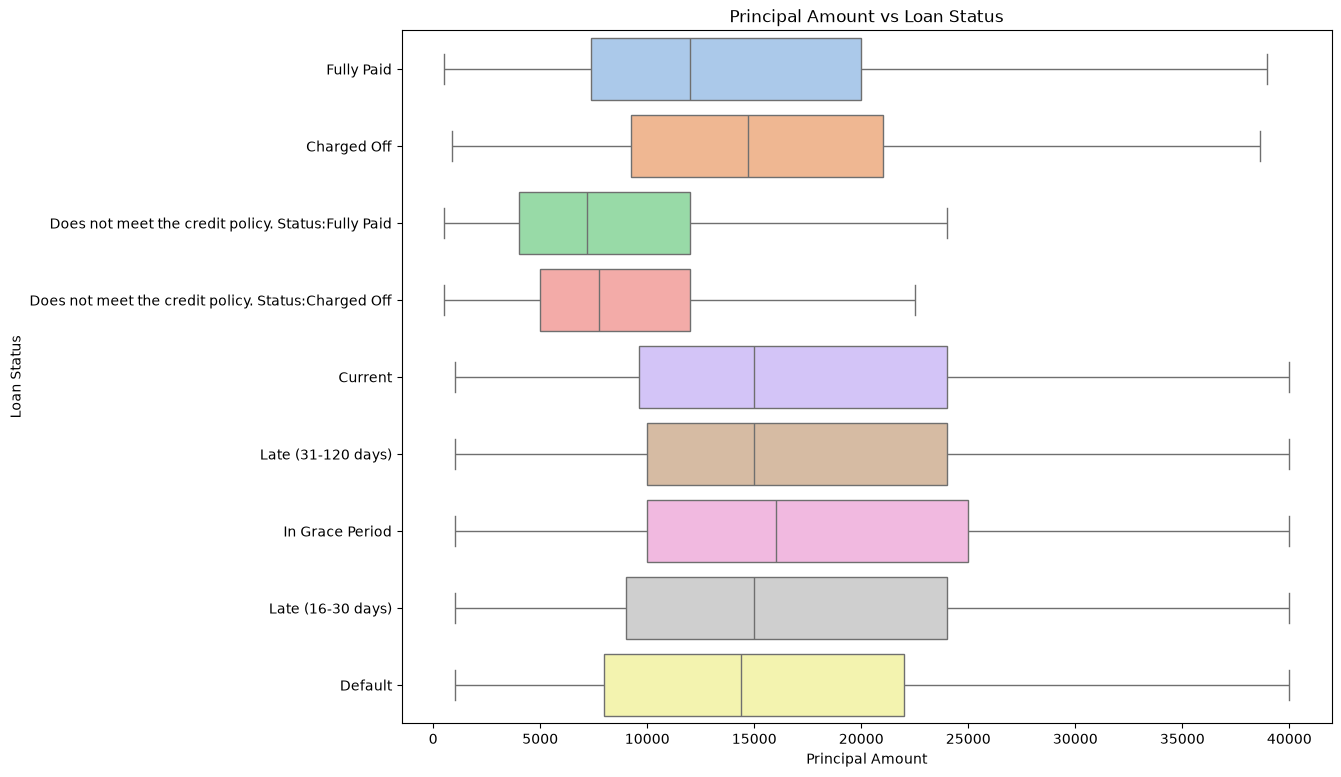

In [82]:
plt.figure(figsize=(12,9))
plot = sns.boxplot(data=processed_df[processed_df['loan_status'] != 'Issued'],
                   x='loan_amnt',y='loan_status',palette='pastel', showfliers=False)
plt.title('Principal Amount vs Loan Status')
plt.xlabel('Principal Amount')
plt.ylabel('Loan Status')
plt.show()

In [83]:
processed_df.groupby('loan_status')['loan_amnt'].agg(Median='median',Mean='mean',Q1=lambda x: x.quantile(0.25),
                                                     Q3=lambda x: x.quantile(0.75)).round(2)

,Median,Mean,Q1,Q3
loan_status,,,,
Charged Off,14700.0,15899.5,9250.0,21000.0
Current,15000.0,16707.17,9600.0,24000.0
Default,14400.0,16193.59,8000.0,22000.0
Does not meet the credit policy. Status:Charged Off,7750.0,9527.23,5000.0,12000.0
Does not meet the credit policy. Status:Fully Paid,7200.0,8853.23,4000.0,12000.0
Fully Paid,12000.0,14270.88,7350.0,20000.0
In Grace Period,16000.0,17909.51,10000.0,25000.0
Issued,14000.0,15956.55,8000.0,21975.0
Late (16-30 days),15000.0,16828.9,9000.0,24000.0


### 4.2 Debt ratio vs repayment behavior

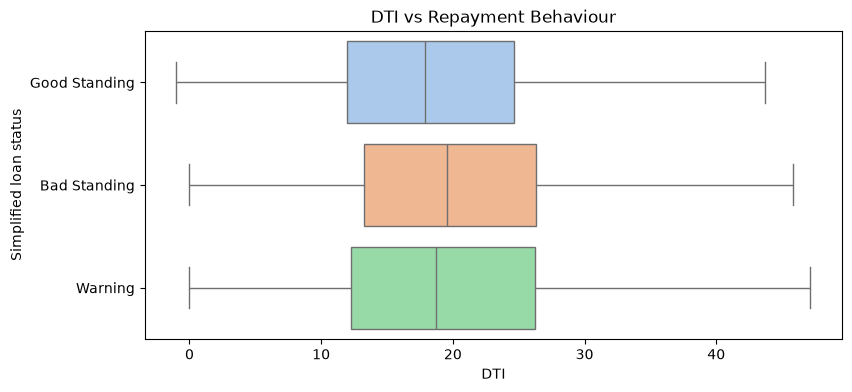

In [84]:
plt.figure(figsize=(9,4))
plot = sns.boxplot(data=processed_df,x='dti',y='simplified_loan_status',palette='pastel', showfliers=False)
plt.title('DTI vs Repayment Behaviour')
plt.xlabel('DTI')
plt.ylabel('Simplified loan status')
plt.show()

In [85]:
processed_df.groupby('simplified_loan_status')['dti'].agg(Median='median',Mean='mean',Q1=lambda x: x.quantile(0.25),
                                                          Q3=lambda x: x.quantile(0.75)).round(2)

,Median,Mean,Q1,Q3
simplified_loan_status,,,,
Bad Standing,19.59,20.27,13.28,26.30
Good Standing,17.90,19.15,11.94,24.64
Warning,18.72,20.72,12.23,26.21


- Borrowers with higher Debt-to-Income (DTI) ratios tend to exhibit slightly poorer repayment behavior. The median DTI increases from **17.90%** for borrowers in *Good Standing* to **19.59%** for borrowers in *Bad Standing*. However, the substantial overlap in interquartile ranges suggests that **DTI alone is not a strong predictor** of repayment behavior and should be considered alongside other credit risk indicators.

### 4.3 Credit history length vs default probability

In [86]:
processed_df['issue_d'] = pd.to_datetime(processed_df['issue_d'],format='%b-%Y')
processed_df['earliest_cr_line'] = pd.to_datetime(processed_df['earliest_cr_line'],format='%b-%Y')
processed_df['credit_history_years'] = ((processed_df['issue_d'] - processed_df['earliest_cr_line']).dt.days / 365.25).round(2)

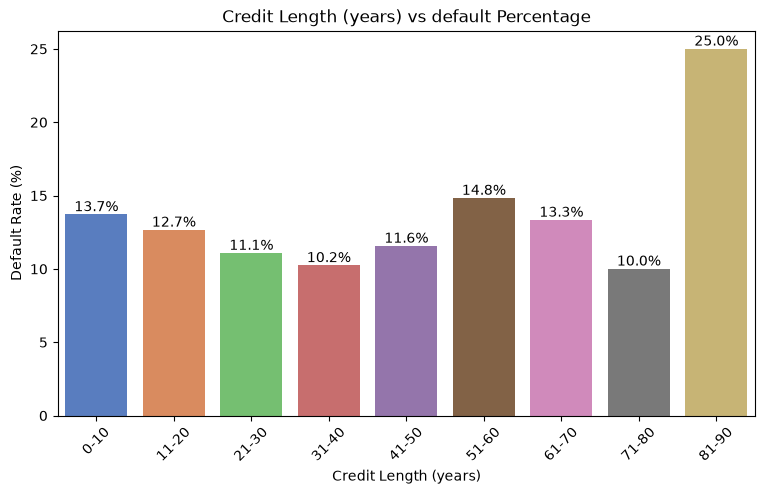

In [87]:
plt.figure(figsize=(9,5))
processed_df['cr_hist_yrs_bin'] = pd.cut(processed_df['credit_history_years'], bins=[0,10,20,30,40,50,60,70,80,90],
                                          labels=['0-10','11-20','21-30','31-40','41-50','51-60','61-70','71-80','81-90']
                                          ,include_lowest = False)
grouped_data = processed_df.groupby('cr_hist_yrs_bin')['is_default'].mean().mul(100).reset_index()
plot = sns.barplot(data=grouped_data,x='cr_hist_yrs_bin',y='is_default',palette='muted',errorbar=None)
plt.title('Credit Length (years) vs default Percentage')
plt.xlabel('Credit Length (years)')
plt.ylabel('Default Rate (%)')

for i in plot.containers:
    plot.bar_label(i, fmt='%.1f%%')
plt.xticks(rotation=45)
plt.show()

### 4.4 Delinquency vs loan performance

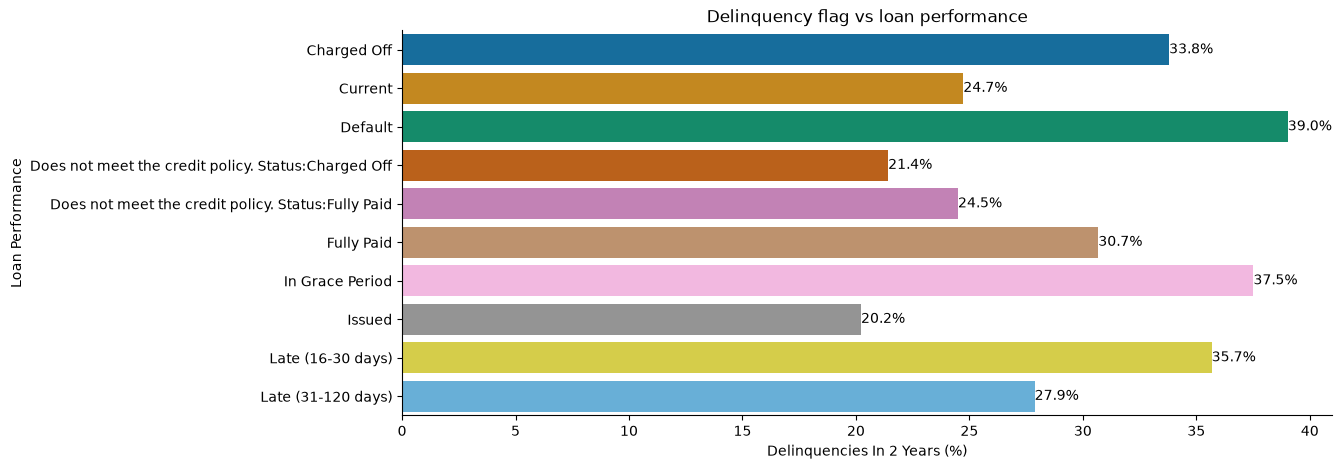

In [88]:
plt.figure(figsize=(12,5))
grouped_data = processed_df.groupby('loan_status')['delinq_2yrs'].mean().mul(100).reset_index()
plot = sns.barplot(data=grouped_data,x='delinq_2yrs',y='loan_status',palette='colorblind',errorbar=None)
plt.title('Delinquency flag vs loan performance')
plt.xlabel('Delinquencies In 2 Years (%)')
plt.ylabel('Loan Performance')

for i in plot.containers:
    plot.bar_label(i, fmt='%.1f%%')
sns.despine(right=True)
plt.show()

### 4.5 Grade levels vs delinquency

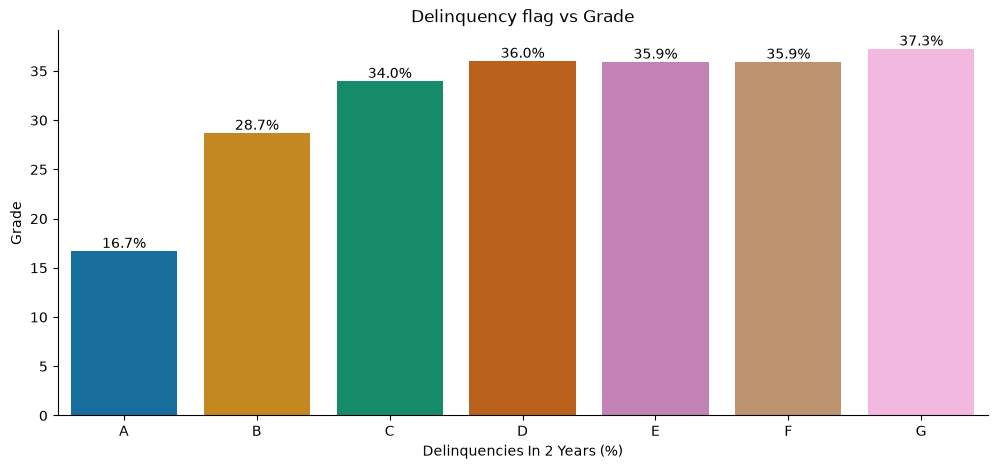

In [89]:
plt.figure(figsize=(12,5))
grouped_data = processed_df.groupby('grade')['delinq_2yrs'].mean().mul(100).reset_index()
plot = sns.barplot(data=grouped_data,x='grade',y='delinq_2yrs',palette='colorblind',errorbar=None)
plt.title('Delinquency flag vs Grade')
plt.xlabel('Delinquencies In 2 Years (%)')
plt.ylabel('Grade')

for i in plot.containers:
    plot.bar_label(i, fmt='%.1f%%')
sns.despine(right=True)
plt.show()

## 5. Time-based Analysis

### 5.1 Loan issue date vs default trends

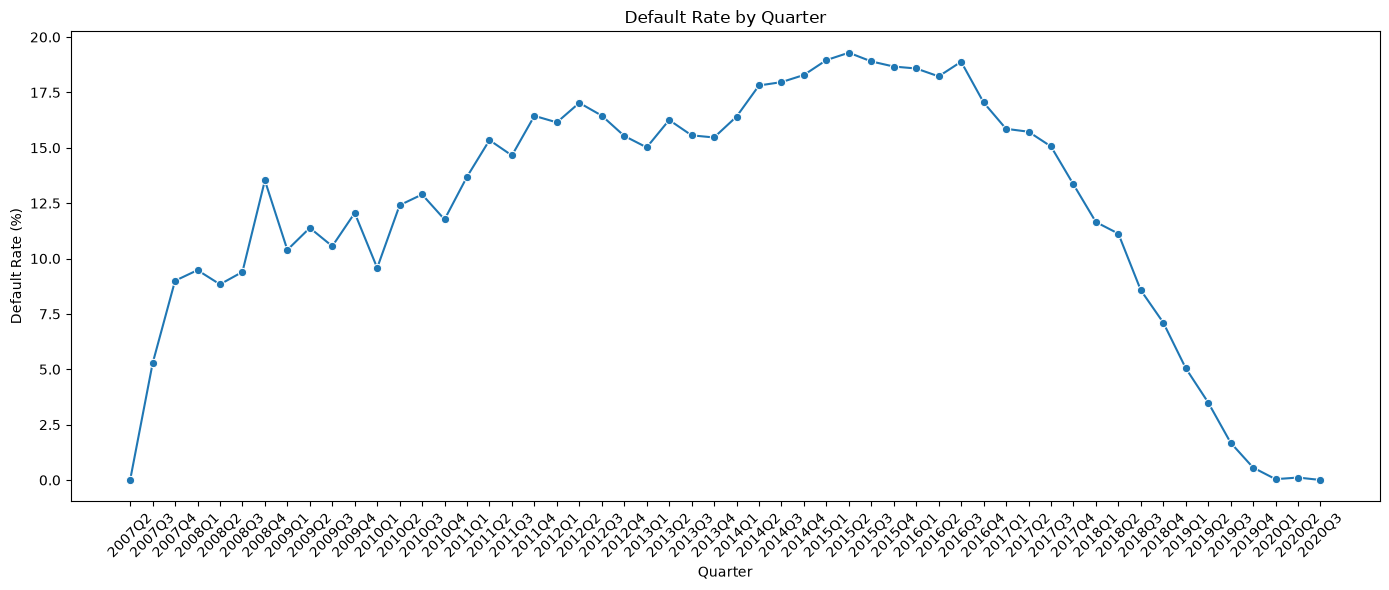

In [90]:
processed_df['quarter'] = processed_df['issue_d'].dt.to_period('Q')
grouped_data = processed_df.groupby('quarter')['is_default'].mean().mul(100).reset_index()
grouped_data['quarter_str'] = grouped_data['quarter'].astype(str)
plt.figure(figsize=(14, 6))
sns.lineplot(data=grouped_data, x='quarter_str', y='is_default', marker='o')

plt.xticks(rotation=45)
plt.title('Default Rate by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

### 5.2 Loan Issued Per Year

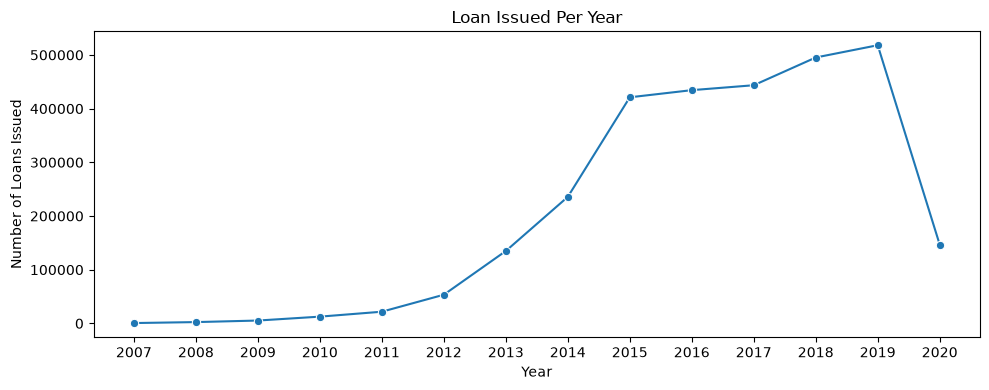

In [91]:
processed_df['issue_Y'] = processed_df['issue_d'].dt.to_period('Y')
grouped_data = processed_df.groupby('issue_Y')['loan_amnt'].count().reset_index()
plt.figure(figsize=(10, 4))
grouped_data['issue_Y_str'] = grouped_data['issue_Y'].astype(str)
sns.lineplot(data=grouped_data, x='issue_Y_str', y='loan_amnt', marker='o')
plt.title('Loan Issued Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Loans Issued')
plt.tight_layout()
plt.show()


### Average loan amount over time

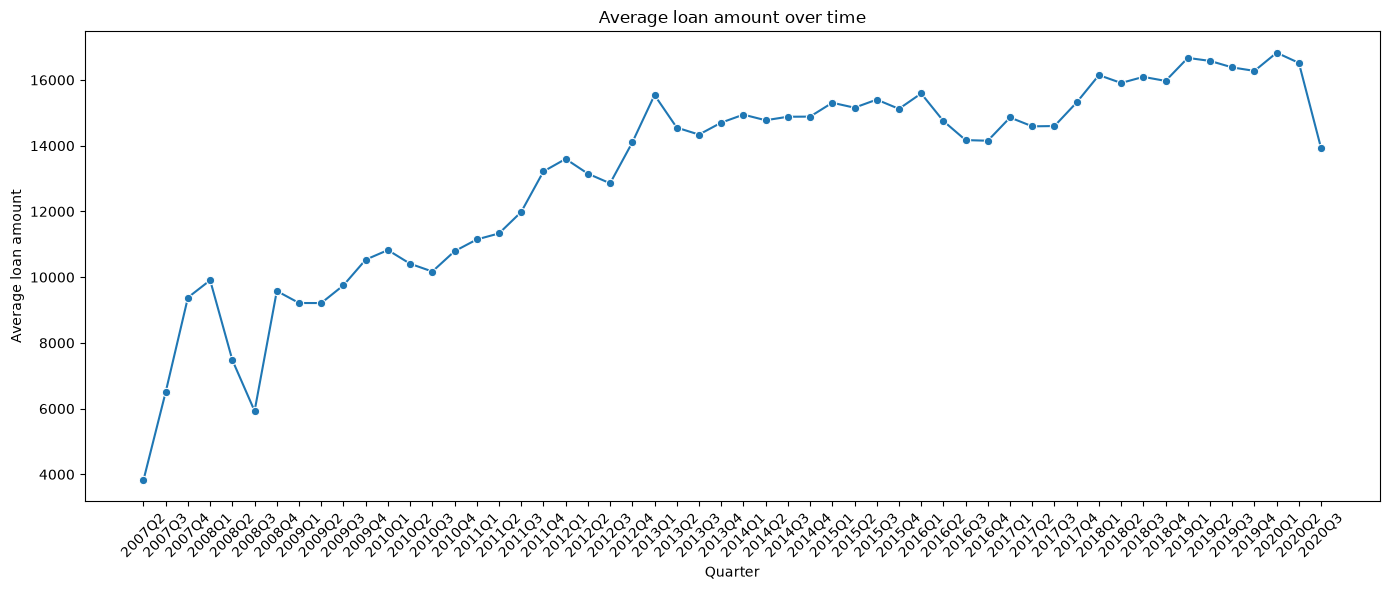

In [92]:
grouped_data = processed_df.groupby('quarter')['loan_amnt'].mean().reset_index()
grouped_data['quarter_str'] = grouped_data['quarter'].astype(str)
plt.figure(figsize=(14, 6))
sns.lineplot(data=grouped_data, x='quarter_str', y='loan_amnt', marker='o')
plt.xticks(rotation=45)
plt.title('Average loan amount over time')
plt.xlabel('Quarter')
plt.ylabel('Average loan amount')
plt.tight_layout()
plt.show()

### 5.4 Loan purpose distribution over time

In [ ]:
purpose_map = {'debt_consolidation':'Personal',
               'credit_card':'Personal',
               'home_improvement':'Home',
               'other':'Other',
               'major_purchase':'Personal',
               'medical':'Medical',
               'small_business':'Business',
               'car':'Personal',
               'vacation':'Personal',
               'house':'Home',
               'moving':'Home',
               'wedding':'Personal',
               'renewable_energy':'Business',
               'educational':'Other'}
processed_df['purpose_map'] = processed_df['purpose'].map(purpose_map)

0    Personal
1    Personal
2    Business
3       Other
4       Other
Name: purpose_map, dtype: str

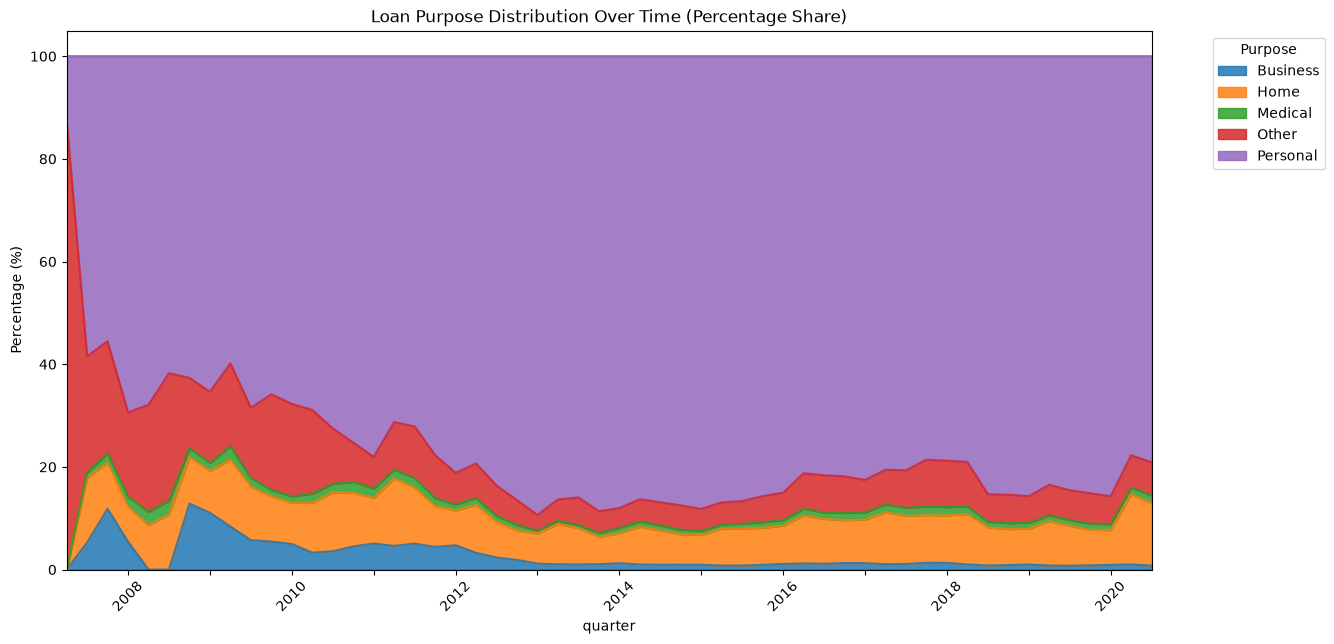

In [106]:
grouped_data = processed_df.groupby(['quarter','purpose_map']).size().unstack(fill_value = 0)
grouped_data_perc = grouped_data.div(grouped_data.sum(axis=1),axis=0)*100
grouped_data_perc.plot(kind='area', stacked=True, figsize=(14, 7), alpha=0.85)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Purpose')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(14))
plt.title('Loan Purpose Distribution Over Time (Percentage Share)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

- The "Personal" Takeover: In 2007, personal loans (purple) were only about half the distribution. By 2013 onwards, they absolutely dominated the platform, consistently taking up nearly 80% of all loan volume.

- The 2008 Crash Anomaly: Look at what happens right around late 2007 into 2008. The "Business" (blue) and "Other" (red) categories spike wildly and then crater. That lines up perfectly with the global financial crisis when small business lending dried up, and people were likely consolidating weird debts ("Other").

- The Squeeze on Everything Else: Because Personal loans grew so aggressively, categories like "Home" (orange) and "Medical" (green) look like stable, thin bands along the bottom, meaning their proportion stayed steady even as overall platform volume grew.

### 5.5 Loan Status Trend Over Time

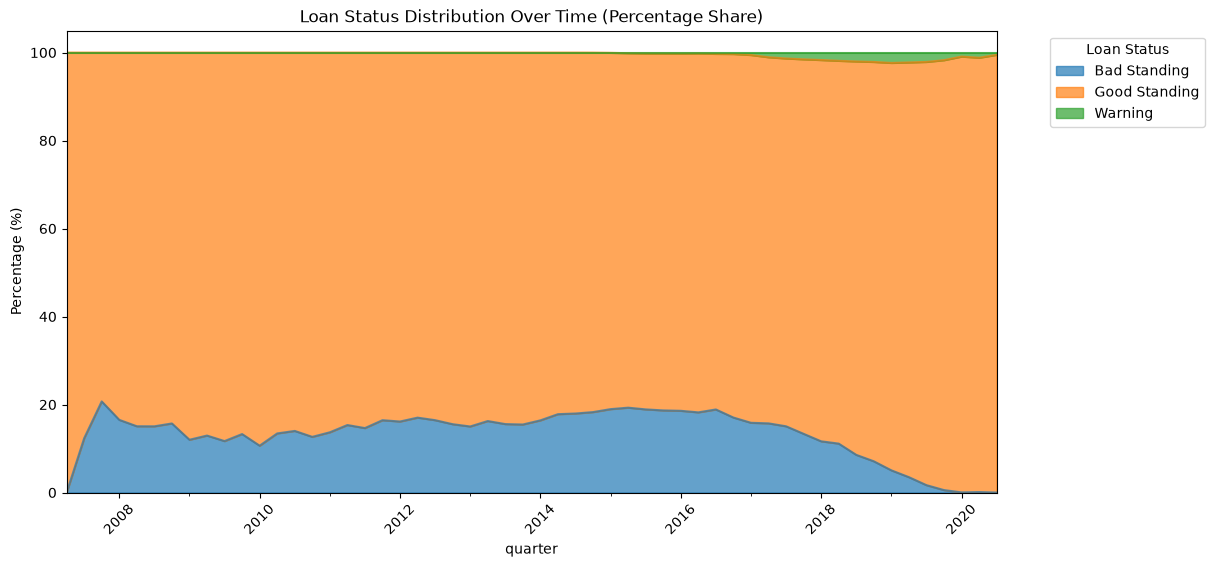

In [122]:
grouped_data = processed_df.groupby(['quarter','simplified_loan_status']).size().unstack(fill_value=0)
grouped_data_perc = grouped_data.div(grouped_data.sum(axis=1),axis=0)*100
grouped_data_perc.plot(kind='area',stacked=True,figsize=(12,6),alpha=0.69)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Loan Status')
plt.title('Loan Status Distribution Over Time (Percentage Share)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

## 6. Correlation Analysis

### 6.1 Median loan amount by grade and year

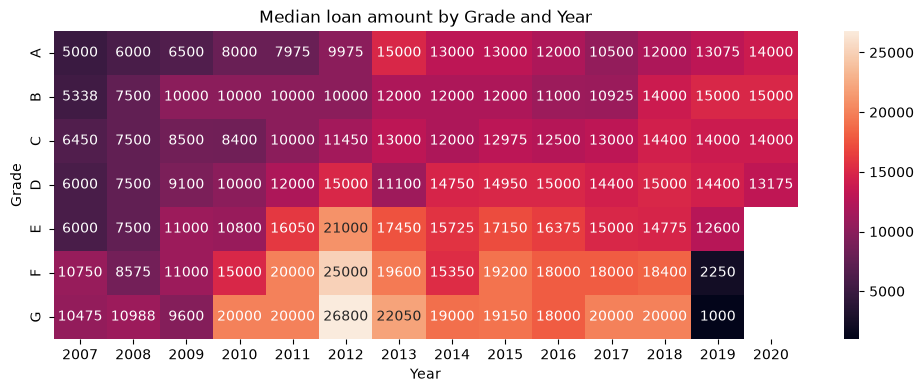

In [159]:
plt.figure(figsize=(12,4))
pivot = processed_df.pivot_table(columns=processed_df['issue_Y'],index='grade',values='loan_amnt',aggfunc='median')
pivot = pivot.astype(float)
sns.heatmap(data=pivot,annot=True, fmt='.0f')
plt.title('Median loan amount by Grade and Year')
plt.xlabel('Year')
plt.ylabel('Grade')
plt.show()

### 6.2 Loan amount vs funded amount

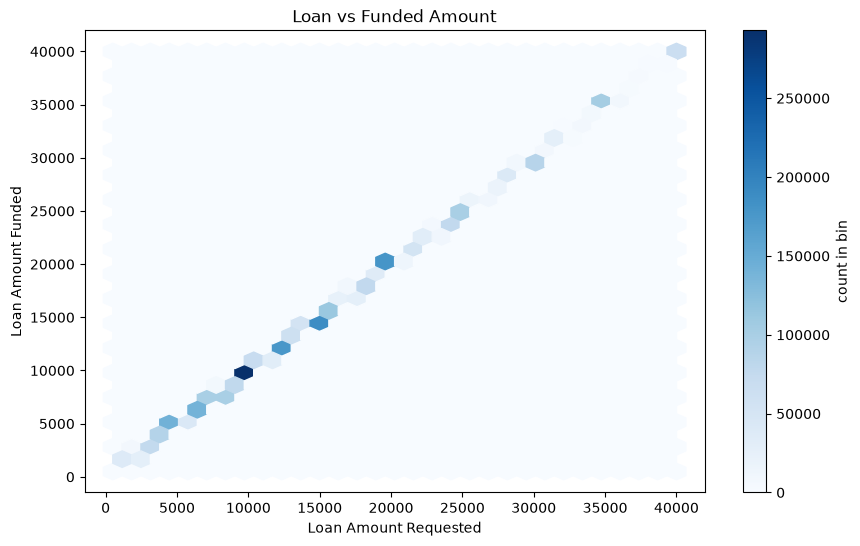

In [172]:
plt.figure(figsize=(10,6))
plt.hexbin(processed_df['loan_amnt'], processed_df['funded_amnt'], gridsize=30, cmap="Blues")
plt.colorbar(label="count in bin")
plt.xlabel("Loan Amount Requested")
plt.ylabel("Loan Amount Funded")
plt.title("Loan vs Funded Amount")
plt.show()

### 6.3 Correlation heatmap with interest rate

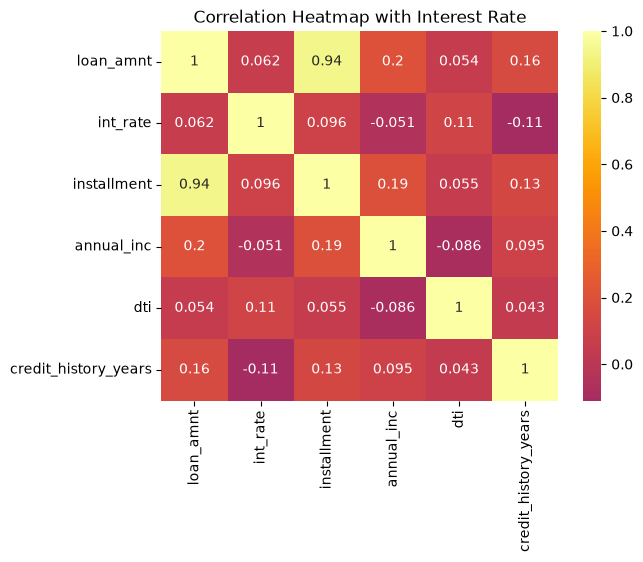

In [191]:
corr = processed_df[['loan_amnt','int_rate','installment','annual_inc','dti','credit_history_years']].corr()
sns.heatmap(corr, annot=True, cmap="inferno", center=0)
plt.title("Correlation Heatmap with Interest Rate")
plt.show()

### 6.4 Loan amount vs installment values

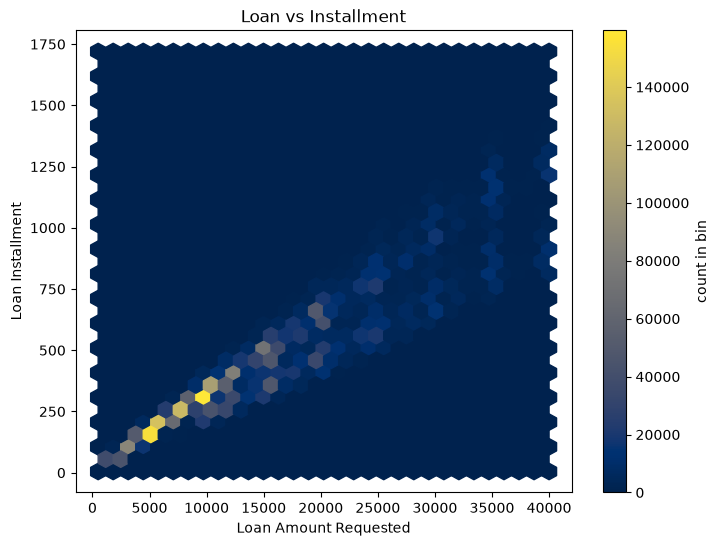

In [199]:
plt.figure(figsize=(8,6))
plt.hexbin(processed_df['loan_amnt'], processed_df['installment'], gridsize=30, cmap="cividis")
plt.colorbar(label="count in bin")
plt.xlabel("Loan Amount Requested")
plt.ylabel("Loan Installment")
plt.title("Loan vs Installment")
plt.show()

### 6.5 Multicollinearity check: total_rec_prncp, principal_paid_ratio, loan_amnt

In [193]:
processed_df['principal_paid_ratio'] = (processed_df['total_rec_prncp'] / processed_df['loan_amnt']).round(2)

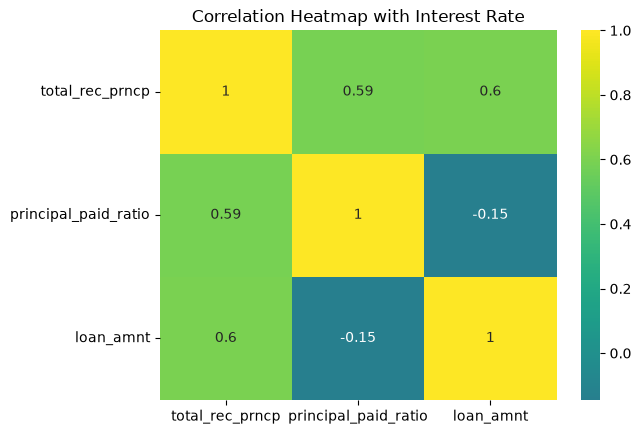

In [194]:
corr = processed_df[['total_rec_prncp', 'principal_paid_ratio', 'loan_amnt']].corr()
sns.heatmap(corr, annot=True, cmap="viridis", center=0)
plt.title("Correlation Heatmap with Interest Rate")
plt.show()

In [200]:
processed_df.to_csv('Analysed Loan Data.csv')

# Loan Data Analysis – Documentation  

## 1. Introduction  
The purpose of this assignment is to explore, clean, and analyze a loan dataset to understand borrower characteristics, loan funding details, repayment performance, and risk-related factors.  

The analysis involves:  
- Data Cleaning  
- Feature Reduction  
- Feature Engineering  
- Exploratory Data Analysis (EDA)  
- Insights from Loan Funding, Borrower Profiles, Loan Status, and Time-based Trends  

---

## 2. Libraries Used  
The following Python libraries were used:  
- **pandas** → Data manipulation and analysis  
- **numpy** → Numerical computations  
- **matplotlib / seaborn** → Data visualization  
- **datetime** → Handling date/time values  


---

## 3. Data Exploration  

### 3.1 Dataset Overview  
- Dataset loaded into a pandas DataFrame.  
- Initial inspection done: shape, column names, data types.  
- Dataset initially had **142 columns**.  

---

## 4. Data Cleaning – 001  

1. **Handling Missing Values**    
   - Removed columns with **>30% missing values**.  
   - Replaced `NaN` in categorical columns: **'emp_title', 'title'** → `"Unknown"`.  
   - Removed rows with missing values in **'last_pymnt_d', 'last_credit_pull_d'** (converted to datetime).  
   - Replaced missing values in numerical columns using **mean imputation**:  
     - `collections_12_mths_ex_med`  
     - `chargeoff_within_12_mths`  
     - `pub_rec_bankruptcies`  
     - `tax_liens`  
   - Filled missing values in **'emp_length'** with `"0 years"`.  

2. **Duplicate Check**  
   - Verified no duplicate rows remained.  

---

## 5. Feature Reduction  

- Classified dataset columns into **categories**:  

| Type | Columns |  
|------|----------|  
| **Discrete (intCols)** | delinq_2yrs, inq_last_6mths, open_acc, pub_rec, revol_bal, total_acc, total_rec_prncp, total_rec_int, pub_rec_bankruptcies |  
| **Continuous (floatCols)** | loan_amnt, funded_amnt, funded_amnt_inv, annual_inc, installment, dti, last_pymnt_amnt, total_pymnt, total_pymnt_inv, revol_util |  
| **Categorical (catCols)** | grade, home_ownership, verification_status, loan_status, purpose, term |  
| **Categorical to Numeric (catColstoNum)** | int_rate, emp_length |  
| **Date (dateCols)** | issue_d, earliest_cr_line |  

- Dropped irrelevant or redundant columns after evaluation.  

---

## 6. Data Cleaning – 002  

- Converted **date columns** (`issue_d`, `earliest_cr_line`, `last_pymnt_d`) to datetime format.  
- Converted **string-based numerical columns** (e.g., `int_rate`, `emp_length`) into numeric values.  
- Finalized column data types for consistency.  

---

## 7. Feature Engineering  

1. **Categorical Encoding**  
   - Applied one-hot encoding and label encoding where required.  

2. **Derived Features**  
   - `fico_score` = ((`fico_range_low`) + (`fico_range_high`))/2
   - `funding_ratio` = `funded_amnt` / `loan_amnt`
   - `int_ratio` = `total_rec_int` / `total_pymnt`
   - `principal_paid_ratio` = `total_rec_prncp` / `loan_amnt`

3. **Bins And Engineered features:**

## Bins and Engineered Features

   | Feature | Description |
   |----------|------------|
   | `dti_bins` | Categorized version of the Debt-to-Income Ratio (`dti`). Groups borrowers into debt burden ranges to simplify the analysis of repayment behavior and default risk. |
   | `delinq_2yrs_bins` | Binned version of `delinq_2yrs`, representing the number of delinquencies reported in the previous two years. Used to analyze how recent credit issues relate to loan performance. |
   | `inq_bins` | Categorized form of the number of credit inquiries made within the last six months. Helps identify whether frequent credit-seeking behavior is associated with higher risk. |
   | `open_acc_bin` | Binned version of `open_acc`, which represents the number of currently open credit accounts. Used to study the relationship between active credit exposure and loan outcomes. |
   | `total_acc_bin` | Categorized version of `total_acc`, representing the total number of credit accounts held by a borrower. Useful for evaluating borrower credit experience and credit profile maturity. |
   | `cr_hist_yrs_bin` | Binned credit history length derived from the borrower's earliest credit line. Used to compare loan performance across different levels of credit history. |
   | `cc_grade` | Creditworthiness category created by binning `fico_score` into five levels: **Poor**, **Fair**, **Good**, **Very Good**, and **Exceptional**. |
   | `purpose_map` | Simplified loan purpose category derived from `purpose`. Original purposes are grouped into **Home**, **Personal**, **Business**, **Medical**, and **Others**. |
   | `purpose_risk_map` | Risk score assigned to each loan purpose. Created by calculating the default rate (`is_default`) for each purpose and mapping that risk level back to all loans belonging to that purpose. |
   | `simplified_loan_status` | Consolidated version of `loan_status` grouped into **Good Standing**, **Warning**, and **Bad Standing** categories. |
   | `is_default` | Binary default indicator. Loans classified as **Bad Standing** are assigned **1**, while all other loans are assigned **0**. |


4. **Final Feature Set**  

**Loan & Funding Information**  
- loan_amnt, funded_amnt, funded_amnt_inv, term, int_rate, installment  

**Borrower Characteristics**  
- grade, emp_length, home_ownership, annual_inc, verification_status  

**Loan Performance & Status**  
- issue_d, loan_status, purpose, dti, delinq_2yrs, earliest_cr_line, inq_last_6mths, open_acc, pub_rec, revol_bal, revol_util, total_acc, total_pymnt, total_pymnt_inv, total_rec_prncp, total_rec_int, last_pymnt_amnt, pub_rec_bankruptcies  

**Engineered Features**  
- fico_score, funding_ratio, int_ratio, principal_paid_ratio, is_default, simplified_loan_status, cc_grade

---

## 8. Conclusion  

- Dataset was successfully cleaned, reduced, and transformed.  
- Derived features such as **debt ratio, principal/interest paid ratio, and credit history years** gave additional insights.  
- Analysis highlighted patterns in loan issuance, borrower demographics, repayment behaviors, and financial risk.  
- Findings can assist in predictive modeling for **loan default classification** and **credit risk management**.  